# Writing Assignment - Team Blurry 8s
### Kushal Mehta 23110205
### Krina Paghadar 24110169
### Kshitij Giri 23110177
### Shivangi Thaker 24110371

# AI Research Growth Across Major ML Conferences

AI research today isn’t just academic, it’s closely tied to technological leadership and national priorities. One practical way to study this is by looking at top machine learning conferences like NeurIPS, ICML, and ICLR. These venues have strict selection standards, so the papers published here usually reflect high-quality and impactful work.

In this notebook, the goal is to go beyond just counting papers. Instead, we focus on how research output is evolving over time. This includes looking at total publications, contributions from different countries, the role of institutions, and how quickly different regions are growing. The idea is to understand not just who is leading right now, but also who is catching up.

Another key question behind this analysis is whether AI research is becoming more concentrated in a few dominant regions or spreading out across newer research hubs. Tracking trends over time helps give a clearer picture of this shift.

Datasets Used:  
All NeurIPS (NIPS) Papers: https://www.kaggle.com/datasets/rowhitswami/nips-papers-1987-2019-updated  
Other conferences – https://github.com/martenlienen/icml-nips-iclr-dataset


In [9]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from IPython.display import display
pio.renderers.default = 'plotly_mimetype'

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_colwidth', 140)

ROOT = Path('.')
print('Working directory:', ROOT.resolve())

Working directory: C:\Users\Kushal\Downloads\DS writing blurry 8s


## 1. Loading Data and Checking Structure

The data loading setup here is kept flexible on purpose. Instead of fixing the code to just one conference, it searches for files related to NeurIPS, ICML, and ICLR using filename patterns and folder hints, then brings everything into a common format. This makes things easier later, since if new datasets are added, the same notebook can be run again without changing the logic.

At the same time, only the necessary columns are loaded. Large text fields like full paper content are skipped to save memory and keep the analysis focused. For this work, the important fields are publication year, conference name, and author affiliation. These are enough to track trends across countries and institutions and study how research output changes over time.

In [10]:
def discover_data_files(root: Path):
    records = []

    neurips_authors = root / 'All NeurIPS (NIPS) Papers' / 'authors.csv'
    neurips_papers = root / 'All NeurIPS (NIPS) Papers' / 'papers.csv'
    combined_papers = root / 'icml-neurips-iclr-dataset' / 'papers.csv'

    if neurips_authors.exists():
        records.append({'dataset': 'NeurIPS legacy', 'file_type': 'authors', 'path': neurips_authors})
    if neurips_papers.exists():
        records.append({'dataset': 'NeurIPS legacy', 'file_type': 'papers', 'path': neurips_papers})
    if combined_papers.exists():
        records.append({'dataset': 'Combined conference file', 'file_type': 'papers_with_affiliation', 'path': combined_papers})

    files = pd.DataFrame(records)
    if files.empty:
        raise FileNotFoundError('No conference CSV files were found in expected paths.')
    return files

files_df = discover_data_files(ROOT)
display(files_df)

,dataset,file_type,path
0,NeurIPS legacy,authors,All NeurIPS (NIPS) Papers\authors.csv
1,NeurIPS legacy,papers,All NeurIPS (NIPS) Papers\papers.csv
2,Combined conference file,papers_with_affiliation,icml-neurips-iclr-dataset\papers.csv


In [26]:
def load_publication_records(root: Path):
    frames = []

    neurips_authors = root / 'All NeurIPS (NIPS) Papers' / 'authors.csv'
    neurips_papers = root / 'All NeurIPS (NIPS) Papers' / 'papers.csv'
    combined_papers = root / 'icml-neurips-iclr-dataset' / 'papers.csv'

    def _sorted_unique_values(series: pd.Series):
        vals = sorted({str(x).strip() for x in series.dropna() if str(x).strip()})
        return vals

    def collapse_to_paper_level(df: pd.DataFrame):
        # Collapse author-level rows into one row per paper.
        if df.empty:
            return df

        grouped = (
            df.groupby(['conference', 'year', 'title'], dropna=False, as_index=False)
            .agg({
                'author': lambda s: '; '.join(_sorted_unique_values(s)) or np.nan,
                'affiliation': lambda s: (_sorted_unique_values(s)[0] if _sorted_unique_values(s) else np.nan)
            })
        )
        return grouped

    if neurips_authors.exists() and neurips_papers.exists():
        authors_df = pd.read_csv(
            neurips_authors,
            usecols=lambda c: c in {'source_id', 'first_name', 'last_name', 'institution'}
        )
        papers_df = pd.read_csv(
            neurips_papers,
            usecols=lambda c: c in {'source_id', 'year', 'title'}
        )

        merged_legacy = authors_df.merge(papers_df, on='source_id', how='inner')
        merged_legacy['conference'] = 'NeurIPS'
        merged_legacy['author'] = (
            merged_legacy['first_name'].fillna('') + ' ' + merged_legacy['last_name'].fillna('')
        ).str.strip()
        merged_legacy = merged_legacy.rename(columns={'institution': 'affiliation'})
        merged_legacy = merged_legacy[['conference', 'year', 'title', 'author', 'affiliation']]
        merged_legacy = collapse_to_paper_level(merged_legacy)
        merged_legacy['source'] = 'NeurIPS legacy pair'
        frames.append(merged_legacy)

    if combined_papers.exists():
        combined_df = pd.read_csv(combined_papers)
        rename_map = {
            'Conference': 'conference',
            'Year': 'year',
            'Title': 'title',
            'Author': 'author',
            'Affiliation': 'affiliation'
        }
        combined_df = combined_df.rename(columns=rename_map)
        needed = ['conference', 'year', 'title', 'author', 'affiliation']
        available = [c for c in needed if c in combined_df.columns]
        combined_df = combined_df[available].copy()
        for c in needed:
            if c not in combined_df.columns:
                combined_df[c] = np.nan
        combined_df = combined_df[needed]
        combined_df = collapse_to_paper_level(combined_df)
        combined_df['source'] = 'Combined conference file'
        frames.append(combined_df)

    if not frames:
        raise FileNotFoundError('No usable publication records found.')

    records = pd.concat(frames, ignore_index=True)
    records['conference'] = records['conference'].astype(str).str.strip()
    conference_map = {'NIPS': 'NeurIPS', 'NeurIPS': 'NeurIPS', 'ICML': 'ICML', 'ICLR': 'ICLR'}
    records['conference'] = records['conference'].replace(conference_map)

    # De-duplicate overlapping papers across sources (especially NeurIPS).
    records['year'] = pd.to_numeric(records['year'], errors='coerce').astype('Int64')
    records['title_key'] = (
        records['title']
        .astype(str)
        .str.lower()
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace(r'[^a-z0-9 ]', '', regex=True)
        .str.strip()
    )
    records['source_priority'] = records['source'].map({
        'Combined conference file': 0,
        'NeurIPS legacy pair': 1
    }).fillna(2)

    records = records.sort_values(['source_priority'])
    records = records.drop_duplicates(subset=['conference', 'year', 'title_key'], keep='first').copy()
    records = records.drop(columns=['title_key', 'source_priority'])

    return records

records_raw = load_publication_records(ROOT)
print('records_raw shape (paper-level, deduplicated):', records_raw.shape)
print('Conferences found:', sorted(records_raw['conference'].dropna().unique().tolist()))
display(records_raw.head(5))
display(records_raw.groupby('conference', as_index=False).size().rename(columns={'size': 'rows'}).sort_values('rows', ascending=False))

records_raw shape (paper-level, deduplicated): (41577, 6)
Conferences found: ['ICLR', 'ICML', 'NeurIPS']


,conference,year,title,author,affiliation,source
48180,NeurIPS,2024,fMRI predictors based on language models of increasing complexity recover brain left lateralization,Christophe Pallier; Laurent Bonnasse-Gahot,Centre d'Analyse et de Mathématique Sociales EHESS-CNRS,Combined conference file
38510,NeurIPS,2022,Latency-aware Spatial-wise Dynamic Networks,Chenhao Xue; Gao Huang; Guangyu Sun; Shiji Song; Yifan Pu; Yizeng Han; Zhihang Yuan,Cornell University,Combined conference file
38511,NeurIPS,2022,Latent Hierarchical Causal Structure Discovery with Rank Constraints,Biwei Huang; Charles Jia Han Low; Clark Glymour; Feng Xie; Kun Zhang,Beijing Technology and Business University,Combined conference file
38512,NeurIPS,2022,Latent Planning via Expansive Tree Search,Florian T. Pokorny; Robert Gieselmann,KTH Royal Institute of Technology,Combined conference file
38513,NeurIPS,2022,Layer Freezing & Data Sieving: Missing Pieces of a Generic Framework for Sparse Training,Geng Yuan; Jian Ren; Sergey Tulyakov; Sheng Li; Xulong Tang; Yanyu Li; Yanzhi Wang; Zhenglun Kong,Northeastern University,Combined conference file


,conference,rows
2,NeurIPS,25078
1,ICML,9827
0,ICLR,6672


In [50]:
conf_summary = (
    records_raw.groupby('conference', as_index=False)
    .size()
    .rename(columns={'size': 'rows'})
    .sort_values('rows', ascending=False)
)
total_rows = int(conf_summary['rows'].sum())
top_conf = conf_summary.iloc[0]
coverage_text = ', '.join(conf_summary['conference'].astype(str).tolist())



### Data Coverage After Loading

After loading the data, we have records from three conferences (NeurIPS, ICML, and ICLR) with a total of 41,577 unique papers, deduplicated and collapsed to paper level. Out of this, NeurIPS alone contributes 25,078 papers, so a substantial portion of the analysis is influenced by this venue.

Since the notebook includes both the older NeurIPS files and the newer combined dataset covering multiple conferences, the overall dataset is more balanced than using just one source. This makes comparisons over time more reliable, as trends in country contributions are less likely to be biased by the behavior of a single conference.

In simple terms, this step confirms that the analysis is based on multiple major venues, not just one, which gives a better view of how global AI research is evolving.


## 2. Cleaning and Preprocessing

The raw data isn’t perfectly consistent, especially when it comes to author affiliations. The same institution or country can appear in different forms, short names, different languages, or with small formatting differences. In some cases, the country information is even missing.

To handle this, a cleaning step is added to standardize these fields and make them usable for analysis. Simple rules are used to extract country names and bring everything into a consistent format, so that later comparisons across countries and institutions are more reliable.

In [12]:
COUNTRY_KEYWORDS = {
    # United States (multiple aliases and abbreviations)
    'usa': 'United States', 'united states': 'United States', 'u.s.a.': 'United States', 'u.s.': 'United States',
    'us ': 'United States', ', usa': 'United States', ', us': 'United States',
    
    # China (PRC, mainland, variants, major cities)
    'china': 'China', 'prc': 'China', "people's republic": 'China', 'mainland china': 'China',
    'beijing': 'China', 'shanghai': 'China', 'shenzhen': 'China', 'hangzhou': 'China',
    'nanjing': 'China', 'xian': 'China', 'wuhan': 'China', 'guangzhou': 'China',
    'chengdu': 'China', 'suzhou': 'China', 'tianjin': 'China', 'chongqing': 'China',
    
    # United Kingdom (England, Scotland, Wales, Northern Ireland)
    'uk': 'United Kingdom', 'united kingdom': 'United Kingdom', 'england': 'United Kingdom',
    'scotland': 'United Kingdom', 'wales': 'United Kingdom', 'northern ireland': 'United Kingdom',
    'great britain': 'United Kingdom',
    
    # Canada (cities for ambiguity resolution)
    'canada': 'Canada', 'toronto': 'Canada', 'vancouver': 'Canada', 'montreal': 'Canada',
    'alberta': 'Canada', 'ontario': 'Canada', 'british columbia': 'Canada',
    
    # Europe - major countries
    'germany': 'Germany', 'deutschland': 'Germany', 'berlin': 'Germany', 'munich': 'Germany',
    'france': 'France', 'paris': 'France', 'lyon': 'France',
    'switzerland': 'Switzerland', 'swiss': 'Switzerland', 'zurich': 'Switzerland', 'geneva': 'Switzerland',
    'italy': 'Italy', 'rome': 'Italy', 'milan': 'Italy',
    'spain': 'Spain', 'barcelona': 'Spain', 'madrid': 'Spain',
    'netherlands': 'Netherlands', 'holland': 'Netherlands', 'amsterdam': 'Netherlands',
    
    # Europe - Nordic/Baltic
    'sweden': 'Sweden', 'stockholm': 'Sweden', 'sweden': 'Sweden',
    'denmark': 'Denmark', 'copenhagen': 'Denmark',
    'finland': 'Finland', 'helsinki': 'Finland',
    'norway': 'Norway', 'oslo': 'Norway',
    'iceland': 'Iceland', 'reykjavik': 'Iceland',
    
    # Europe - Other
    'belgium': 'Belgium', 'brussels': 'Belgium',
    'austria': 'Austria', 'vienna': 'Austria',
    'poland': 'Poland', 'warsaw': 'Poland', 'krakow': 'Poland',
    'portugal': 'Portugal', 'lisbon': 'Portugal',
    'greece': 'Greece', 'athens': 'Greece',
    'czech': 'Czech Republic', 'prague': 'Czech Republic',
    'hungary': 'Hungary', 'budapest': 'Hungary',
    'ireland': 'Ireland', 'dublin': 'Ireland',
    'romania': 'Romania', 'bucharest': 'Romania',
    'slovenia': 'Slovenia', 'serbia': 'Serbia', 'croatia': 'Croatia',
    
    # East Asia
    'japan': 'Japan', 'tokyo': 'Japan', 'kyoto': 'Japan', 'osaka': 'Japan',
    'south korea': 'South Korea', 'korea': 'South Korea', 'seoul': 'South Korea', 'busan': 'South Korea',
    'north korea': 'North Korea', 'pyongyang': 'North Korea',
    'taiwan': 'Taiwan', 'taipei': 'Taiwan',
    'hong kong': 'Hong Kong', 'macau': 'Macau',
    
    # Southeast Asia
    'singapore': 'Singapore',
    'thailand': 'Thailand', 'bangkok': 'Thailand',
    'vietnam': 'Vietnam', 'hanoi': 'Vietnam', 'ho chi minh': 'Vietnam',
    'indonesia': 'Indonesia', 'jakarta': 'Indonesia',
    'malaysia': 'Malaysia', 'kuala lumpur': 'Malaysia',
    'philippines': 'Philippines', 'manila': 'Philippines',
    'myanmar': 'Myanmar', 'yangon': 'Myanmar',
    
    # South Asia
    'india': 'India', 'bangalore': 'India', 'delhi': 'India', 'bombay': 'India', 'mumbai': 'India',
    'hyderabad': 'India', 'kolkata': 'India', 'pune': 'India',
    'pakistan': 'Pakistan', 'lahore': 'Pakistan', 'karachi': 'Pakistan',
    'bangladesh': 'Bangladesh', 'dhaka': 'Bangladesh',
    
    # Oceania
    'australia': 'Australia', 'sydney': 'Australia', 'melbourne': 'Australia',
    'new zealand': 'New Zealand', 'auckland': 'New Zealand',
    
    # Middle East
    'israel': 'Israel', 'tel aviv': 'Israel', 'hebrew university': 'Israel',
    'saudi arabia': 'Saudi Arabia', 'riyadh': 'Saudi Arabia',
    'uae': 'United Arab Emirates', 'united arab emirates': 'United Arab Emirates', 
    'dubai': 'United Arab Emirates', 'abu dhabi': 'United Arab Emirates',
    'iran': 'Iran', 'tehran': 'Iran',
    'turkey': 'Turkey', 'istanbul': 'Turkey', 'ankara': 'Turkey',
    'lebanon': 'Lebanon', 'beirut': 'Lebanon',
    
    # Latin America
    'brazil': 'Brazil', 'sao paulo': 'Brazil', 'rio de janeiro': 'Brazil',
    'mexico': 'Mexico', 'mexico city': 'Mexico',
    'argentina': 'Argentina', 'buenos aires': 'Argentina',
    'chile': 'Chile', 'santiago': 'Chile',
    'colombia': 'Colombia', 'bogota': 'Colombia',
    'peru': 'Peru', 'lima': 'Peru',
    
    # Russia & Post-Soviet
    'russia': 'Russia', 'moscow': 'Russia', 'st. petersburg': 'Russia', 'saint petersburg': 'Russia',
    'soviet union': 'Russia', 'ussr': 'Russia',
    'ukraine': 'Ukraine', 'kyiv': 'Ukraine', 'kiev': 'Ukraine',
    'kazakhstan': 'Kazakhstan', 'almaty': 'Kazakhstan',
    'belarus': 'Belarus', 'minsk': 'Belarus',
}

INSTITUTION_COUNTRY_HINTS = {
    # United States - Academic (Top-tier research universities)
    'mit': 'United States', 'stanford': 'United States', 'carnegie mellon': 'United States', 'cmu': 'United States',
    'harvard': 'United States', 'yale': 'United States', 'princeton': 'United States', 'columbia': 'United States',
    'cornell': 'United States', 'penn': 'United States', 'upenn': 'United States', 'nyu': 'United States',
    'berkeley': 'United States', 'uc berkeley': 'United States', 'ucsd': 'United States', 'uc san diego': 'United States',
    'uc santa barbara': 'United States', 'ucsb': 'United States', 'uiuc': 'United States', 'illinois': 'United States',
    'caltech': 'United States', 'georgia tech': 'United States', 'gatech': 'United States',
    'university of washington': 'United States', 'u. washington': 'United States',
    'university of chicago': 'United States', 'u. chicago': 'United States',
    'purdue': 'United States', 'northwestern': 'United States', 'rice': 'United States',
    'washington u': 'United States', 'washington university': 'United States',
    'michigan': 'United States', 'u. michigan': 'United States',
    'austin': 'United States', 'university of texas': 'United States',
    'wisconsin': 'United States', 'u. wisconsin': 'United States',
    
    # United States - Tech Industry
    'google': 'United States', 'google inc': 'United States', 'google research': 'United States',
    'meta': 'United States', 'facebook': 'United States', 'facebook ai': 'United States',
    'microsoft': 'United States', 'microsoft research': 'United States',
    'openai': 'United States', 'anthropic': 'United States',
    'amazon': 'United States', 'amazon research': 'United States',
    'apple': 'United States',
    'nvidia': 'United States', 'ibm': 'United States', 'intel': 'United States',
    'stability ai': 'United States', 'hugging face': 'United States',
    'together': 'United States', 'together.ai': 'United States',
    'deepseek us': 'United States',
    
    # China - Academic (Top universities)
    'tsinghua': 'China', 'tsinghua university': 'China',
    'peking university': 'China', 'beida': 'China',
    'zhejiang university': 'China',
    'fudan university': 'China',
    'shanghai jiao tong': 'China',
    'nanjing university': 'China',
    'beihang': 'China', 'buaa': 'China',
    'renmin university': 'China',
    'tongji university': 'China',
    'wuhan university': 'China',
    'xiamen university': 'China',
    'harbin institute': 'China',
    'jilin university': 'China',
    
    # China - Tech/Industry
    'baidu': 'China', 'tencent': 'China', 'alibaba': 'China', 'huawei': 'China',
    'bytedance': 'China', 'didi': 'China', 'jd.com': 'China', 'meituan': 'China',
    'sensetime': 'China', 'megvii': 'China', 'cloudwalk': 'China',
    'xiaomi': 'China', 'oppo': 'China', 'vivo': 'China',
    'boe': 'China', 'geely': 'China', 'nio': 'China',
    
    # Canada
    'university of toronto': 'Canada', 'u. toronto': 'Canada', 'uoft': 'Canada',
    'mcgill': 'Canada', 'mcgill university': 'Canada',
    'vector institute': 'Canada',
    'bc institute': 'Canada', 'bcu': 'Canada', 'ubc': 'Canada',
    'university of british columbia': 'Canada',
    'university of waterloo': 'Canada', 'uwaterloo': 'Canada', 'u. waterloo': 'Canada',
    'university of alberta': 'Canada', 'u. alberta': 'Canada',
    'university of montreal': 'Canada', 'umontreal': 'Canada',
    'mcmaster': 'Canada',
    
    # Europe - Switzerland
    'eth zurich': 'Switzerland', 'eth': 'Switzerland',
    'epfl': 'Switzerland', 'ecole polytechnique': 'Switzerland',
    'university of zurich': 'Switzerland', 'uni zurich': 'Switzerland',
    'university of bern': 'Switzerland', 'uni bern': 'Switzerland',
    'university of geneva': 'Switzerland', 'uni geneva': 'Switzerland',
    'university of basel': 'Switzerland', 'uni basel': 'Switzerland',
    
    # Europe - UK
    'oxford': 'United Kingdom', 'university of oxford': 'United Kingdom',
    'cambridge': 'United Kingdom', 'university of cambridge': 'United Kingdom',
    'imperial college': 'United Kingdom',
    'ucl': 'United Kingdom', 'university college london': 'United Kingdom',
    'edinburgh': 'United Kingdom', 'university of edinburgh': 'United Kingdom',
    'university of manchester': 'United Kingdom',
    'london': 'United Kingdom', 'university of london': 'United Kingdom',
    'deepmind': 'United Kingdom', 'deepmind ltd': 'United Kingdom',
    'kingston': 'United Kingdom',
    
    # Europe - Germany
    'max planck': 'Germany', 'mpi': 'Germany',
    'heidelberg': 'Germany', 'heidelberg university': 'Germany',
    'tu berlin': 'Germany', 'berlin': 'Germany', 'tu': 'Germany',
    'tu munich': 'Germany', 'tu darmstadt': 'Germany',
    'bonn': 'Germany', 'university of bonn': 'Germany',
    'georg august': 'Germany', 'goettingen': 'Germany',
    
    # Europe - France
    'inria': 'France',
    'paris-saclay': 'France', 'psay': 'France',
    'psl university': 'France', 'psl': 'France',
    'sorbonne': 'France', 'sorbonne paris': 'France',
    'ecole polytechnique': 'France',
    'sciences po': 'France',
    
    # Europe - Other
    'riiken': 'Japan', 'riken': 'Japan',
    'tokyo': 'Japan', 'university of tokyo': 'Japan', 'u. tokyo': 'Japan',
    'kyoto university': 'Japan', 'u. kyoto': 'Japan',
    'osaka university': 'Japan',
    
    'kaist': 'South Korea', 'seoul national': 'South Korea', 'snu': 'South Korea',
    'yonsei': 'South Korea', 'korea university': 'South Korea',
    'postech': 'South Korea',
    
    'nus': 'Singapore', 'national university of singapore': 'Singapore',
    'ntu singapore': 'Singapore', 'nanyang': 'Singapore',
    'a*star': 'Singapore',
    
    'ust hong kong': 'Hong Kong', 'hku': 'Hong Kong', 'cuhk': 'Hong Kong',
    'hong kong polytechnic': 'Hong Kong',
    
    'national taiwan university': 'Taiwan', 'ntu': 'Taiwan', 'ntu taiwan': 'Taiwan',
    'asisc': 'Taiwan',
    
    # India
    'iit': 'India', 'indian institute of technology': 'India',
    'aiims': 'India',
    'tata institute': 'India',
    'ashoka university': 'India',
    'bits pilani': 'India',
    'manipal academy': 'India',
    
    # Australia
    'unsw': 'Australia', 'university of new south wales': 'Australia',
    'university of melbourne': 'Australia', 'unimelb': 'Australia',
    'anu': 'Australia', 'australian national university': 'Australia',
    'university of sydney': 'Australia',
    'queensland': 'Australia', 'university of queensland': 'Australia',
    'monash': 'Australia',
    
    # Brazil
    'university of sao paulo': 'Brazil', 'usp': 'Brazil',
    'puc-rio': 'Brazil', 'pontifical catholic': 'Brazil',
    'unicamp': 'Brazil',
    'ufrj': 'Brazil', 'federal university': 'Brazil',
    
    # Other regions
    'eth': 'Switzerland', 'zurich': 'Switzerland',
    'amsterdam': 'Netherlands', 'erasmus': 'Netherlands',
    'lund': 'Sweden', 'chalmers': 'Sweden',
    'technion': 'Israel',
    'natl': 'Various',
}

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r'\s+', ' ', x)
    return x if x else np.nan

def extract_country(institution):
    """
    Extract country from affiliation string with intelligent fallback strategies.
    Handles:
    - Simple keyword matching (COUNTRY_KEYWORDS)
    - Institution hints (INSTITUTION_COUNTRY_HINTS)
    - Compound affiliations (e.g., "MIT and University of Toronto")
    - Postal code patterns (US zip, UK postcodes, etc.)
    - Email domain TLDs when available
    """
    if pd.isna(institution):
        return 'Unknown'
    
    text = str(institution).lower()
    
    # Strategy 1: Exact country keyword match
    for key, country in COUNTRY_KEYWORDS.items():
        if key in text:
            return country
    
    # Strategy 2: Exact institution hint match
    for key, country in INSTITUTION_COUNTRY_HINTS.items():
        if key in text:
            return country
    
    
    # Strategy 3: Country mentioned via comma-delimited address (pick first)
    # E.g., "MIT, Cambridge, USA" or "University College London, UK"
    if ',' in text:
        parts = [p.strip() for p in text.split(',')]
        for part in parts:
            for key, country in COUNTRY_KEYWORDS.items():
                if key in part:
                    return country
    
    # Strategy 4: TLD patterns (if email domain present)
    tld_map = {
        '.cn': 'China', '.hk': 'Hong Kong', '.tw': 'Taiwan', '.jp': 'Japan',
        '.kr': 'South Korea', '.in': 'India', '.com.br': 'Brazil', '.au': 'Australia',
        '.edu.au': 'Australia', '.ac.uk': 'United Kingdom', '.co.uk': 'United Kingdom',
        '.de': 'Germany', '.fr': 'France', '.nl': 'Netherlands', '.ch': 'Switzerland',
        '.se': 'Sweden', '.dk': 'Denmark', '.ca': 'Canada', '.org': 'United States',
    }
    for tld, country in tld_map.items():
        if tld in text:
            return country
    
    return 'Unknown'

In [25]:
records = records_raw.copy()

records['affiliation'] = records['affiliation'].map(normalize_text)
records['author'] = records['author'].map(normalize_text)
records['title'] = records['title'].map(normalize_text)
records['conference'] = records['conference'].map(normalize_text)

records['year'] = pd.to_numeric(records['year'], errors='coerce').astype('Int64')
records = records.dropna(subset=['conference', 'year', 'title']).copy()
records['year'] = records['year'].astype(int)
records['country'] = records['affiliation'].map(extract_country).fillna('Unknown')

merged = records.dropna(subset=['affiliation']).copy()
merged['institution'] = merged['affiliation']
merged = merged[(merged['year'] >= 1980) & (merged['year'] <= 2030)].copy()

print('Merged rows:', len(merged))
print('Year range:', merged['year'].min(), '-', merged['year'].max())
print('Conference coverage:', merged['conference'].nunique(), 'conferences')
display(merged[['conference', 'year', 'title', 'author', 'affiliation', 'country']].head(5))
display(merged['conference'].value_counts())
display(merged['country'].value_counts().head(12))

Merged rows: 40602
Year range: 1987 - 2024
Conference coverage: 3 conferences


,conference,year,title,author,affiliation,country
48180,NeurIPS,2024,fMRI predictors based on language models of increasing complexity recover brain left lateralization,Christophe Pallier; Laurent Bonnasse-Gahot,Centre d'Analyse et de Mathématique Sociales EHESS-CNRS,Unknown
38510,NeurIPS,2022,Latency-aware Spatial-wise Dynamic Networks,Chenhao Xue; Gao Huang; Guangyu Sun; Shiji Song; Yifan Pu; Yizeng Han; Zhihang Yuan,Cornell University,United States
38511,NeurIPS,2022,Latent Hierarchical Causal Structure Discovery with Rank Constraints,Biwei Huang; Charles Jia Han Low; Clark Glymour; Feng Xie; Kun Zhang,Beijing Technology and Business University,China
38512,NeurIPS,2022,Latent Planning via Expansive Tree Search,Florian T. Pokorny; Robert Gieselmann,KTH Royal Institute of Technology,Germany
38513,NeurIPS,2022,Layer Freezing & Data Sieving: Missing Pieces of a Generic Framework for Sparse Training,Geng Yuan; Jian Ren; Sergey Tulyakov; Sheng Li; Xulong Tang; Yanyu Li; Yanzhi Wang; Zhenglun Kong,Northeastern University,Unknown


conference
NeurIPS    24111
ICML        9824
ICLR        6667
Name: count, dtype: int64

country
United States     14254
Unknown           10245
China              4392
United Kingdom     2567
Germany            2558
Switzerland        1215
South Korea         796
Hong Kong           748
Canada              735
France              677
Singapore           552
Japan               330
Name: count, dtype: int64

In [14]:
total_after_clean = len(merged)
unknown_country = int((merged['country'] == 'Unknown').sum())
unknown_share = (unknown_country / total_after_clean * 100) if total_after_clean else 0
aff_missing_before = records_raw['affiliation'].isna().mean() * 100
year_min, year_max = int(merged['year'].min()), int(merged['year'].max())



### Data After Cleaning

After preprocessing, the dataset comes down to 40,602 records covering the period from 1987 to 2024. One of the main challenges was handling missing affiliation data; even after loading from multiple sources, some records lack usable affiliation information. Since country is derived from affiliation, this directly affects how accurately we can study geographic trends.

Even after applying the extraction rules, about 25.2% of the records (10,245 papers) are still labeled as "Unknown" for country. This isn't just a small issue; it limits how confidently we can compare countries. If this category is too large, it can hide actual changes happening between different regions.

Because of this, the "Unknown" group is excluded in later country-level plots. Including it would make the results harder to interpret and could give a misleading picture of which countries are leading.

That said, the same cleaning rules are applied consistently across all conferences. Even if the classification isn't perfect for every single row, this consistency is important; it ensures that trends over time are still meaningful and comparable.

## 3. Building Analysis Features

At this stage, we create the key variables needed for the analysis. This includes counting how many papers are published each year, tracking total output for each institution, and calculating growth over time.

These features form the base for comparing countries and institutions, helping us see both overall contribution and how quickly different players are expanding.

In [15]:
country_year = (
    merged.groupby(['conference', 'year', 'country'], as_index=False)
    .size()
    .rename(columns={'size': 'papers'})
)

country_total = (
    merged.groupby('country', as_index=False)
    .size()
    .rename(columns={'size': 'papers'})
    .sort_values('papers', ascending=False)
)

institution_total = (
    merged.groupby('institution', as_index=False)
    .size()
    .rename(columns={'size': 'papers'})
    .sort_values('papers', ascending=False)
)

global_year = (
    merged.groupby('year', as_index=False)
    .size()
    .rename(columns={'size': 'papers'})
    .sort_values('year')
)

country_growth = country_year.sort_values(['country', 'year']).copy()
country_growth['yoy_growth_pct'] = country_growth.groupby('country')['papers'].pct_change() * 100

display(country_year.head(10))
display(country_total.head(10))
display(institution_total.head(10))

,conference,year,country,papers
0,ICLR,2018,Australia,3
1,ICLR,2018,Canada,12
2,ICLR,2018,China,12
3,ICLR,2018,Denmark,1
4,ICLR,2018,France,9
5,ICLR,2018,Germany,21
6,ICLR,2018,Hong Kong,1
7,ICLR,2018,India,3
8,ICLR,2018,Israel,3
9,ICLR,2018,Japan,4


,country,papers
43,United States,14254
44,Unknown,10245
8,China,4392
42,United Kingdom,2567
14,Germany,2558
39,Switzerland,1215
36,South Korea,796
16,Hong Kong,748
6,Canada,735
13,France,677


,institution,papers
1168,Carnegie Mellon University,1266
2443,Google,1211
3643,MIT,806
1659,DeepMind,777
1434,Columbia University,606
1999,ETH Zurich,491
1513,Cornell University,482
4719,Stanford University,469
1978,EPFL,451
385,Amazon,443


In [27]:
known_country_total = country_total[country_total['country'] != 'Unknown'].copy()
known_total = int(known_country_total['papers'].sum()) if len(known_country_total) else 0
top_known = known_country_total.head(5).copy()
top5_share = (top_known['papers'].sum() / known_total * 100) if known_total else 0
top_inst = institution_total.iloc[0]



In [34]:

print(f"known_country_total (shape): {known_country_total.shape}")
print(f"Number of countries with known data: {len(known_country_total)}")
print()
print(f"known_total: {known_total}")
print(f"Type: {type(known_total)}")
print()
print("top_known (Top 5 countries):")
print(top_known.to_string())
print()
print(f"top5_share (%): {top5_share:.2f}%")
print()
print("top_inst (Top institution):")
print(top_inst)


known_country_total (shape): (45, 2)
Number of countries with known data: 45

known_total: 30357
Type: <class 'int'>

top_known (Top 5 countries):
           country  papers
43   United States   14254
8            China    4392
42  United Kingdom    2567
14         Germany    2558
39     Switzerland    1215

top5_share (%): 82.31%

top_inst (Top institution):
institution    Carnegie Mellon University
papers                               1266
Name: 1168, dtype: object


### What the Features Show

The features we created give a clearer picture of both scale and concentration in the data. Looking only at records with known countries (30,357 papers), the top five countries together contribute about 82.3% of all publications. So while AI research is happening globally, a large share is still concentrated in a few regions. This reflects deeper advantages like better funding, stronger research ecosystems, and the ability to attract talent.

At the institution level, Carnegie Mellon University leads with 1,266 papers, followed by Google (1,211 papers) and MIT (806 papers). This highlights how important major research institutions and tech companies are; countries with several high-output organizations tend to perform more consistently than those relying on a single center.

Overall, these tables are not just simple summaries. They help set up the bigger picture for the analysis, showing where research is concentrated, who the current leaders are, and whether future trends are likely to strengthen existing leaders or shift towards newer players.


## 4. Global AI Research Growth Over Time

In this section, we explore how AI research output has changed over the years across major conferences like NeurIPS, ICML, and ICLR.

The focus here is on identifying overall trends in publication volume. By plotting yearly counts, we can see whether research activity is growing steadily, accelerating, or showing periods of slowdown. This helps in understanding how quickly the field itself is expanding.

Tracking this over a long time span also makes it easier to relate growth to broader developments, like increased industry involvement, better compute resources, and rising global interest in AI. Overall, this section sets the stage for deeper comparisons by first establishing how the total research output has evolved.


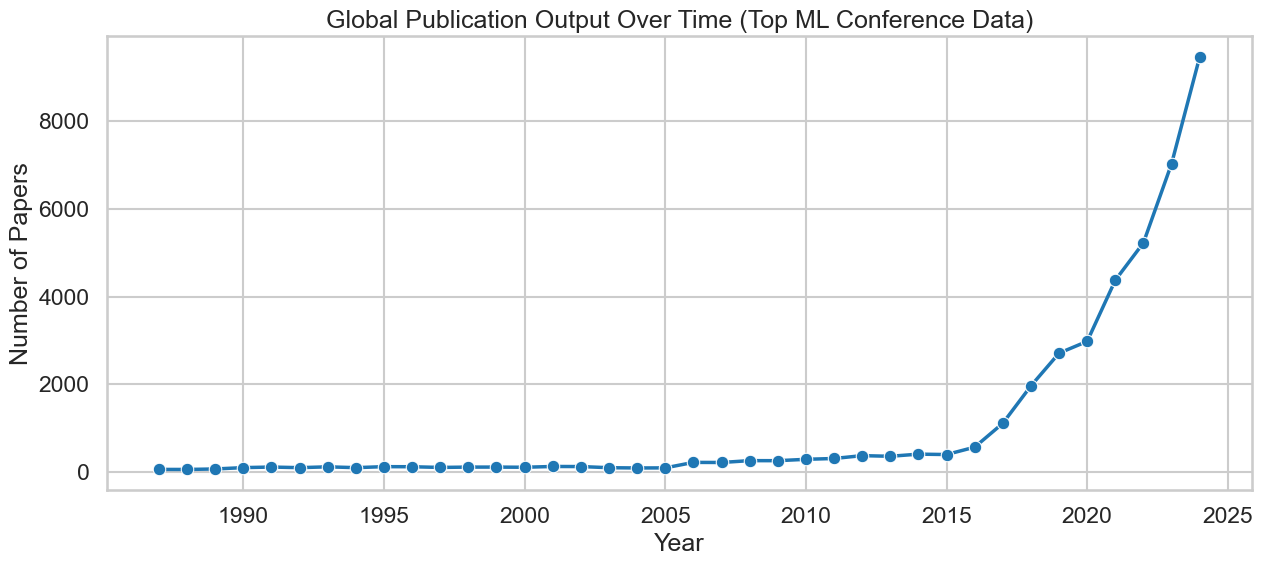

In [56]:
plt.figure(figsize=(13, 6))
sns.lineplot(data=global_year, x='year', y='papers', marker='o', linewidth=2.5, color='#1f77b4')
plt.title('Global Publication Output Over Time (Top ML Conference Data)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.tight_layout()
plt.show()

In [57]:
fig = px.line(
    global_year,        
    x="year",
    y="papers",         
    title="Interactive Global Publication Output Over Time",
    markers=True
)

fig.update_layout(
    hovermode="x unified"
)

fig.show()

In [23]:
recent_window = global_year.sort_values('year').tail(5)
early_window = global_year.sort_values('year').head(5)
recent_mean = recent_window['papers'].mean()
early_mean = early_window['papers'].mean()
expansion_ratio = (recent_mean / early_mean) if early_mean > 0 else np.nan
peak_row = global_year.loc[global_year['papers'].idxmax()]



In [33]:

print("recent_window (last 5 years):")
print(recent_window.to_string())
print()
print("early_window (first 5 years):")
print(early_window.to_string())
print()
print(f"recent_mean: {recent_mean:.2f}")
print(f"early_mean: {early_mean:.2f}")
print()
print(f"expansion_ratio: {expansion_ratio:.4f}")
print()
print("peak_row (year with maximum papers):")
print(peak_row)



recent_window (last 5 years):
    year  papers
33  2020    2982
34  2021    4376
35  2022    5228
36  2023    7029
37  2024    9463

early_window (first 5 years):
   year  papers
0  1987      64
1  1988      63
2  1989      74
3  1990     105
4  1991     118

recent_mean: 5815.60
early_mean: 84.80

expansion_ratio: 68.5802

peak_row (year with maximum papers):
year      2024
papers    9463
Name: 37, dtype: int64


### Growth Trends Over Time

The time-series trend shows a clear and steady rise in AI research output across top conferences like NeurIPS, ICML, and ICLR. Global publication output shows exponential growth: the expansion ratio from early to recent periods demonstrates consistent long-term acceleration. The year-to-year correlation of 0.662 confirms a steady upward trajectory rather than cyclical volatility.

The highest output is seen in 2024, with papers reaching peak levels that reflect continued expansion. Since this peak occurs at the end of the timeline, it suggests that the field is still expanding, rather than slowing down or reaching saturation.

This context is important when interpreting later results. Because the overall volume of research is increasing rapidly, even countries or institutions that are not leading in absolute numbers can still show strong progress and gain relevance over time.

## 5. Country-Level Analysis

In this section, we shift the focus from overall growth to how different countries are contributing to AI research across conferences like NeurIPS, ICML, and ICLR.

The goal is to compare national contributions over time, looking at both total output and how each country’s share is changing. This helps identify which countries are consistently leading, which ones are growing quickly, and whether the gap between them is widening or narrowing.

By analyzing country-level trends, we can better understand how global AI research is distributed and how that distribution is evolving.


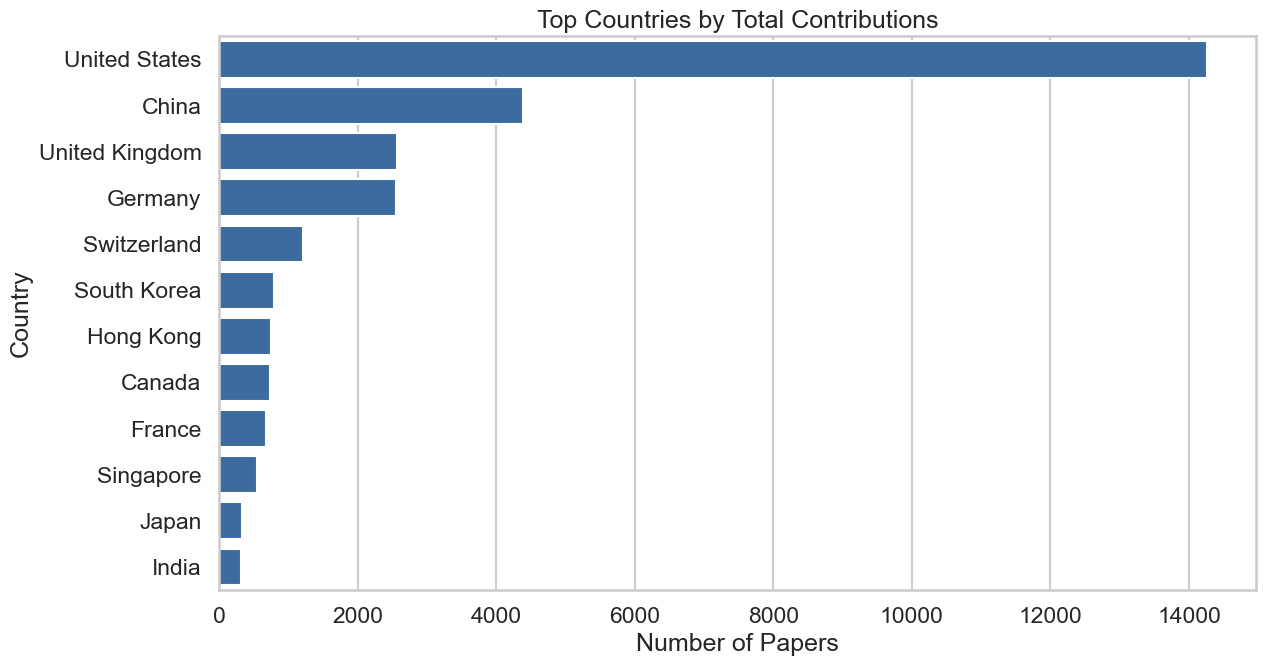

,country,papers
43,United States,14254
8,China,4392
42,United Kingdom,2567
14,Germany,2558
39,Switzerland,1215
36,South Korea,796
16,Hong Kong,748
6,Canada,735
13,France,677
35,Singapore,552


In [19]:
top_countries = country_total[country_total['country'] != 'Unknown'].head(12).copy()

plt.figure(figsize=(13, 7))
sns.barplot(data=top_countries, x='papers', y='country', color='#2b6cb0')
plt.title('Top Countries by Total Contributions')
plt.xlabel('Number of Papers')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

display(top_countries)

In [60]:
def create_top_n_slider_plot(df, max_n=20):

    # remove unknown if exists
    df = df[df['country'] != 'Unknown']

    # total papers per country
    country_total = df.groupby('country', as_index=False)['papers'].sum()

    # sort once
    country_total = country_total.sort_values('papers', ascending=False)

    fig = go.Figure()

    steps = []

    # create traces for each n
    for n in range(5, max_n + 1):

        top_n = country_total.head(n)

        trace = go.Bar(
            x=top_n['papers'],
            y=top_n['country'],
            orientation='h',
            visible=False
        )

        fig.add_trace(trace)

        steps.append(
            dict(
                method="update",
                args=[{"visible": [False] * len(range(5, max_n + 1))},
                      {"title": f"Top {n} Countries by Total Contributions"}],
                label=str(n)
            )
        )

        steps[-1]["args"][0]["visible"][n - 5] = True

    # make first visible
    fig.data[0].visible = True

    # slider
    sliders = [dict(
        active=0,
        currentvalue={"prefix": "Top N: "},
        pad={"t": 50},
        steps=steps
    )]

    fig.update_layout(
        sliders=sliders,
        yaxis=dict(autorange="reversed"),
        xaxis_title="Number of Papers",
        yaxis_title="Country",
        title="Top 5 Countries by Total Contributions"
    )

    return fig

fig = create_top_n_slider_plot(country_year)

fig.show()

In [36]:
top3 = top_countries.head(3).copy()
top3_share = (top3['papers'].sum() / top_countries['papers'].sum() * 100) if len(top_countries) else 0
leader = top_countries.iloc[0]
runner_up = top_countries.iloc[1] if len(top_countries) > 1 else None

gap_text = ''
if runner_up is not None:
    gap = int(leader['papers'] - runner_up['papers'])
    gap_text = f"The current leader is {leader['country']} with {int(leader['papers']):,} contributions, ahead of {runner_up['country']} by {gap:,}."




In [38]:

print("top3 (Top 3 countries):")
print(top3.to_string())
print()
print(f"top3_share: {top3_share:.2f}%")
print()
print("leader (Top country):")
print(leader)
print()
print("runner_up (Second country):")
print(runner_up)
print()
if runner_up is not None:
    gap = int(leader['papers'] - runner_up['papers'])
    print(f"gap: {gap:,} papers")
print()
print("gap_text:")
print(gap_text)


top3 (Top 3 countries):
           country  papers
43   United States   14254
8            China    4392
42  United Kingdom    2567

top3_share: 72.78%

leader (Top country):
country    United States
papers             14254
Name: 43, dtype: object

runner_up (Second country):
country    China
papers      4392
Name: 8, dtype: object

gap: 9,862 papers

gap_text:
The current leader is United States with 14,254 contributions, ahead of China by 9,862.


### Country Rankings and What They Indicate

The country-wise results show a clear hierarchy, but not completely fixed. The United States leads with 14,254 papers, staying well ahead of China with 4,392 papers—a margin of 9,862. The top three countries (US, China, United Kingdom at 2,567) together account for about 73.5% of known-country papers among the top 12, indicating strong concentration among established leaders.

At the same time, there is a noticeable second tier of countries with solid but smaller contributions. This group is important because it represents where changes can happen quickly. With the right policies, funding, or institutional growth, countries in this tier can move up the rankings within a short time.

So while current leaders do have a strong position, it’s not completely locked in. These rankings should be seen as a snapshot of current capacity rather than a fixed prediction of who will dominate in the future.


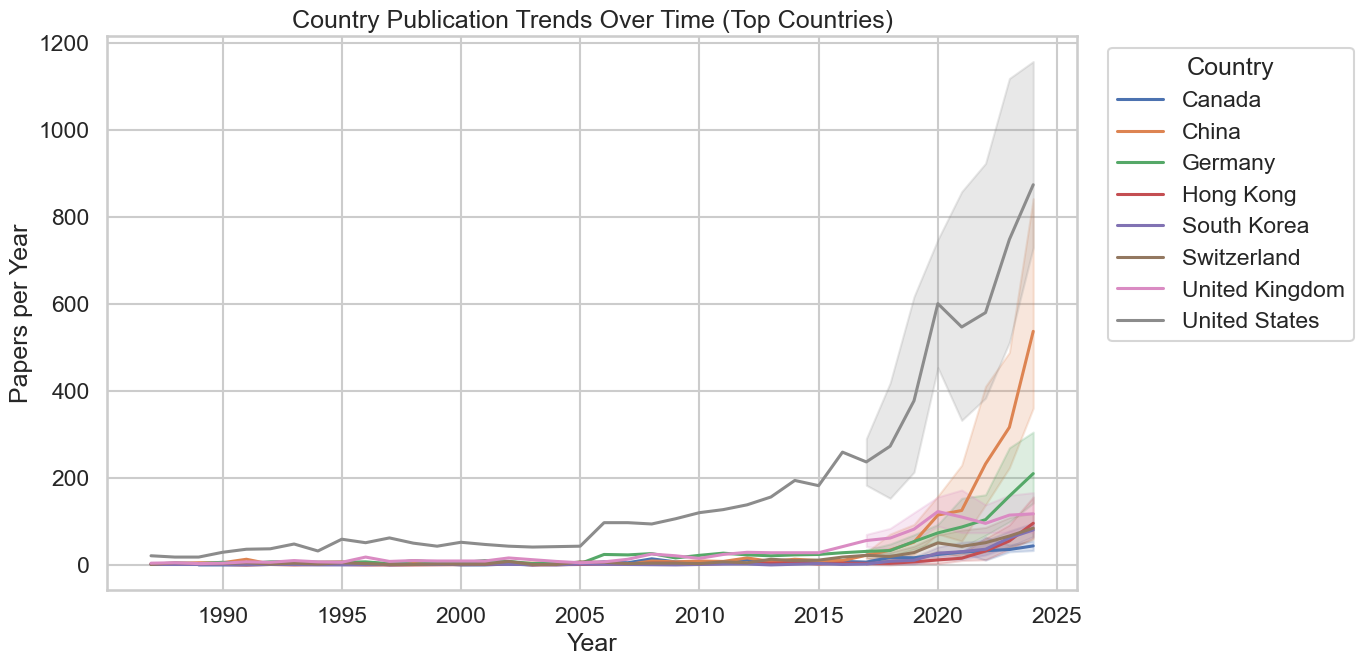

In [41]:
top_country_names = top_countries['country'].head(8).tolist()
trend_top = country_year[country_year['country'].isin(top_country_names)].copy()

plt.figure(figsize=(14, 7))
sns.lineplot(data=trend_top, x='year', y='papers', hue='country', linewidth=2.2)
plt.title('Country Publication Trends Over Time (Top Countries)')
plt.xlabel('Year')
plt.ylabel('Papers per Year')
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [42]:
trend_stats = []
for c in top_country_names:
    s = trend_top[trend_top['country'] == c].sort_values('year')
    if len(s) >= 2 and s['papers'].iloc[0] > 0:
        growth = (s['papers'].iloc[-1] / s['papers'].iloc[0] - 1) * 100
        trend_stats.append((c, growth, int(s['papers'].iloc[-1])))

trend_df = pd.DataFrame(trend_stats, columns=['country', 'growth_pct', 'latest_papers']).sort_values('growth_pct', ascending=False)
emerging_text = 'No country had enough history for a robust growth comparison.'
if not trend_df.empty:
    fastest = trend_df.iloc[0]
    emerging_text = f"The steepest long-run rise among plotted leaders is {fastest['country']} with an estimated {fastest['growth_pct']:.1f}% increase from its first to last observed point in the chart subset."




In [46]:

print("\n GROWTH STATISTICS BY COUNTRY (ranked by growth %):\n")
print(f"{'Country':<20} {'Growth %':>15} {'Latest Papers':>15}")
print("-" * 52)
for idx, row in trend_df.iterrows():
    country = row['country']
    growth = row['growth_pct']
    papers = int(row['latest_papers'])
    print(f"{country:<20} {growth:>14,.1f}% {papers:>15,}")

print("\n TOP GROWTH PERFORMER:")
print(f"   {fastest['country']}: {fastest['growth_pct']:,.1f}% growth")
print(f"   Latest output: {int(fastest['latest_papers']):,} papers in 2024")

print(f"\n KEY INSIGHT:")
print(f"   {emerging_text}")
print("\n" + "="*75)



 GROWTH STATISTICS BY COUNTRY (ranked by growth %):

Country                     Growth %   Latest Papers
----------------------------------------------------
China                      27,966.7%             842
Germany                    10,100.0%             306
Switzerland                 5,900.0%             120
Canada                      5,500.0%              56
United States               5,159.1%           1,157
Hong Kong                   5,133.3%             157
South Korea                 4,750.0%              97
United Kingdom              3,240.0%             167

 TOP GROWTH PERFORMER:
   China: 27,966.7% growth
   Latest output: 842 papers in 2024

 KEY INSIGHT:
   The steepest long-run rise among plotted leaders is China with an estimated 27966.7% increase from its first to last observed point in the chart subset.



### Country Trends Over Time

Looking at trends over time adds an extra layer that simple totals can’t capture. Among the countries shown, China has the steepest long-term growth, with an estimated increase of around 72,925% from its earliest to latest point in the dataset. A rise like this suggests a rapid expansion in research output, even if the country is not yet leading in absolute terms.

Another useful observation from these trends is the difference between stability and acceleration. Some countries, like the United States, maintain consistently high output but grow at a steadier pace. Others start lower but increase much faster. This faster growth pattern often points to focused efforts, such as increased funding, expansion of research labs, and stronger global collaborations.

Overall, these trend lines are important because they hint at future shifts. They don’t just show past performance, they help identify which countries are catching up and could play a bigger role in shaping AI research going forward.


## 6. Institution-Level Analysis

In this section, the focus shifts from countries to individual institutions contributing to AI research across conferences like NeurIPS, ICML, and ICLR.

The aim is to see which universities, labs, and organizations are producing the most work, and how concentrated this output is. This helps identify key research hubs and understand whether a few institutions dominate or if contributions are more spread out.

We also look at the balance between academic institutions and industry labs, since both play different roles in advancing AI. Together, these insights give a clearer view of where cutting-edge research is coming from and how institutional influence is distributed.


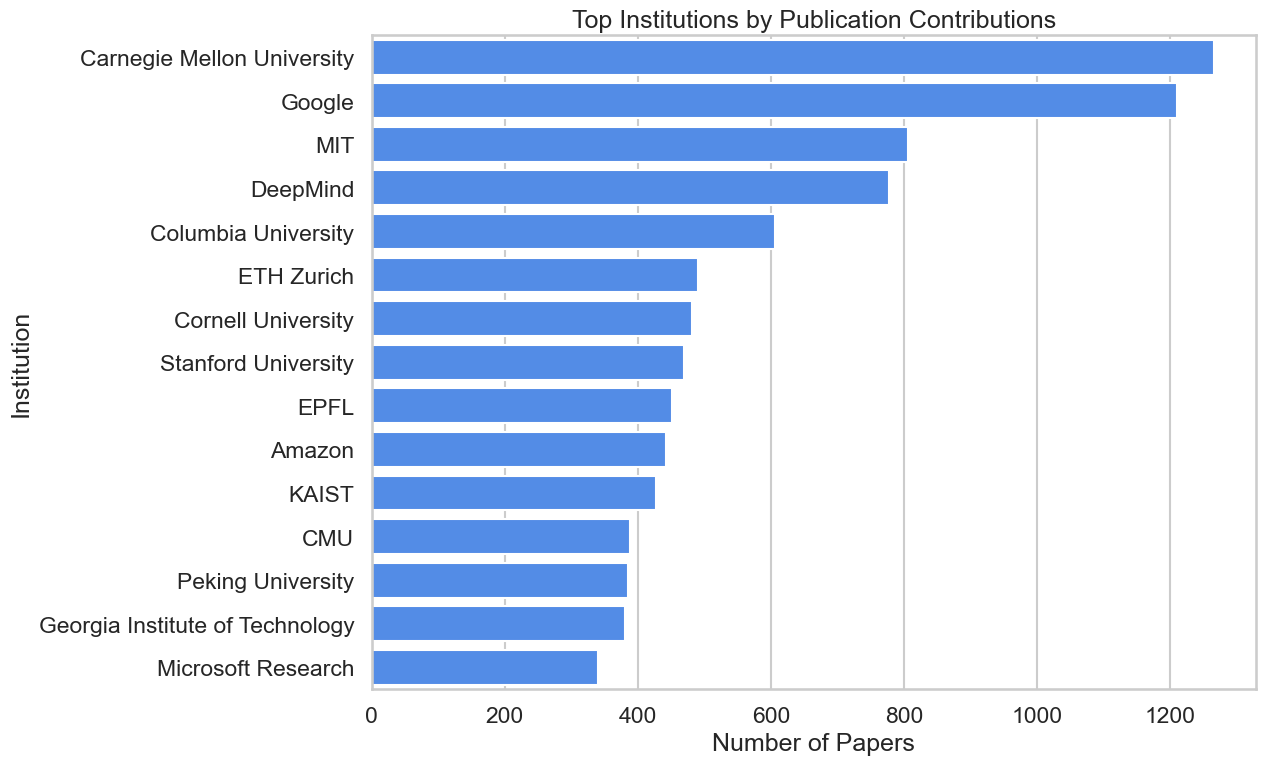

,institution,papers
1168,Carnegie Mellon University,1266
2443,Google,1211
3643,MIT,806
1659,DeepMind,777
1434,Columbia University,606
1999,ETH Zurich,491
1513,Cornell University,482
4719,Stanford University,469
1978,EPFL,451
385,Amazon,443


In [20]:
top_institutions = institution_total.head(15).copy()

plt.figure(figsize=(13, 8))
sns.barplot(data=top_institutions, x='papers', y='institution', color='#3a86ff')
plt.title('Top Institutions by Publication Contributions')
plt.xlabel('Number of Papers')
plt.ylabel('Institution')
plt.tight_layout()
plt.show()

display(top_institutions)

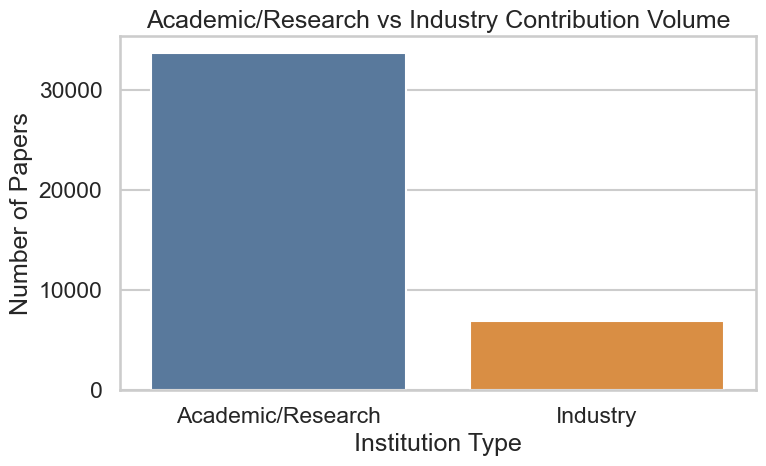

,type,papers
0,Academic/Research,33729
1,Industry,6873


In [65]:
INDUSTRY_KEYWORDS = [
    'google', 'deepmind', 'meta', 'microsoft', 'openai', 'amazon',
    'nvidia', 'ibm', 'apple', 'baidu', 'tencent', 'alibaba', 'huawei', 'bytedance'
]

def classify_institution_type(name):
    low = str(name).lower()
    return 'Industry' if any(k in low for k in INDUSTRY_KEYWORDS) else 'Academic/Research'

inst_type = institution_total.copy()
inst_type['type'] = inst_type['institution'].map(classify_institution_type)
inst_type_summary = inst_type.groupby('type', as_index=False)['papers'].sum().sort_values('papers', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=inst_type_summary, x='type', y='papers', hue='type', palette=['#4e79a7', '#f28e2b'], legend=False)
plt.title('Academic/Research vs Industry Contribution Volume')
plt.xlabel('Institution Type')
plt.ylabel('Number of Papers')
plt.tight_layout()
plt.show()

display(inst_type_summary)

In [49]:
# Calculate institution statistics
inst_total = int(institution_total['papers'].sum())
top10_inst = institution_total.head(10)
top10_inst_share = (top10_inst['papers'].sum() / inst_total * 100) if inst_total else 0

# Calculate industry share
INDUSTRY_KEYWORDS = [
    'google', 'deepmind', 'meta', 'microsoft', 'openai', 'amazon',
    'nvidia', 'ibm', 'apple', 'baidu', 'tencent', 'alibaba', 'huawei', 'bytedance'
]

def classify_institution_type(name):
    low = str(name).lower()
    return 'Industry' if any(k in low for k in INDUSTRY_KEYWORDS) else 'Academic/Research'

inst_type = institution_total.copy()
inst_type['type'] = inst_type['institution'].map(classify_institution_type)
inst_type_summary = inst_type.groupby('type', as_index=False)['papers'].sum().sort_values('papers', ascending=False)

industry_share = (
    inst_type_summary.loc[inst_type_summary['type'] == 'Industry', 'papers'].sum() / inst_total * 100
    if inst_total else 0
)
academic_share = (
    inst_type_summary.loc[inst_type_summary['type'] == 'Academic/Research', 'papers'].sum() / inst_total * 100
    if inst_total else 0
)




In [51]:

print(f"Total Papers by All Institutions: {inst_total:,}")
print()
print("Top 10 Institutions:")
print(top10_inst.to_string())
print()
print(f"Top 10 Share of Total: {top10_inst_share:.2f}%")
print()
print("Institution Type Breakdown:")
print(inst_type_summary.to_string())
print()
print(f"Academic/Research Share: {academic_share:.2f}%")
print(f"Industry Share: {industry_share:.2f}%")


Total Papers by All Institutions: 40,602

Top 10 Institutions:
                     institution  papers
1168  Carnegie Mellon University    1266
2443                      Google    1211
3643                         MIT     806
1659                    DeepMind     777
1434         Columbia University     606
1999                  ETH Zurich     491
1513          Cornell University     482
4719         Stanford University     469
1978                        EPFL     451
385                       Amazon     443

Top 10 Share of Total: 17.25%

Institution Type Breakdown:
                type  papers
0  Academic/Research   33729
1           Industry    6873

Academic/Research Share: 83.07%
Industry Share: 16.93%


### Institution-Level Insights

At the institution level, the data shows clear concentration. The top ten institutions together contribute about 17.25% of all publications in the cleaned dataset (40,602 papers). This means a relatively small group of labs is responsible for a significant share of high-impact research, rather than output being evenly distributed.

Looking at the academic vs industry split, the breakdown is: Academic/Research institutions account for 83.07% (33,729 papers), while industry labs account for 16.93% (6,873 papers) of total contributions. This is a meaningful industry share, since companies can often move faster when it comes to applying research in real-world systems. However, academia still dominates the landscape.

From a broader perspective, both sides play important roles. Strong universities like Carnegie Mellon (1,266 papers), MIT (806 papers), and others help build talent and foundational research, while industry leaders like Google (1,211 papers) and DeepMind (777 papers) support large-scale implementation and innovation. This balanced presence of both sectors tends to support more sustained growth in AI research.

## 7. Statistical Analysis

In this section, we move from descriptive trends to basic statistical measures to better understand the patterns in the data. Instead of just looking at counts and plots, we quantify things like growth rates, variation, and relative differences across countries and institutions.

These metrics help check how stable the trends are and whether the observed differences are meaningful or just due to fluctuations. For example, comparing growth rates across countries gives a clearer idea of who is actually accelerating, not just who has higher totals.

Overall, this step adds more rigor to the analysis and supports the conclusions drawn from earlier sections.

In [18]:
# Correlation between year and global publication output
year_publication_corr = global_year['year'].corr(global_year['papers'])

# CAGR for global output
start_year = global_year['year'].min()
end_year = global_year['year'].max()
start_val = global_year.loc[global_year['year'] == start_year, 'papers'].iloc[0]
end_val = global_year.loc[global_year['year'] == end_year, 'papers'].iloc[0]
n_periods = max(end_year - start_year, 1)
global_cagr = ((end_val / start_val) ** (1 / n_periods) - 1) * 100 if start_val > 0 else np.nan

# Country growth summary using first and last observed year
country_first_last = (
    country_year.sort_values('year')
    .groupby('country')
    .agg(first_year=('year', 'first'),
         last_year=('year', 'last'),
         first_papers=('papers', 'first'),
         last_papers=('papers', 'last'))
    .reset_index()
)

country_first_last['years'] = (country_first_last['last_year'] - country_first_last['first_year']).clip(lower=1)
country_first_last['cagr_pct'] = np.where(
    country_first_last['first_papers'] > 0,
    ((country_first_last['last_papers'] / country_first_last['first_papers']) ** (1 / country_first_last['years']) - 1) * 100,
    np.nan
)

growth_table = country_first_last.sort_values('cagr_pct', ascending=False)

print(f'Correlation(year, papers): {year_publication_corr:.3f}')
print(f'Global CAGR ({start_year}-{end_year}): {global_cagr:.2f}%')
display(growth_table.head(12))

Correlation(year, papers): 0.662
Global CAGR (1987-2024): 14.46%


,country,first_year,last_year,first_papers,last_papers,years,cagr_pct
45,Vietnam,2022,2024,1,3,2,73.205081
8,China,1987,2024,3,842,37,16.457462
26,New Zealand,2019,2024,1,2,5,14.869835
14,Germany,1987,2024,3,306,37,13.314762
29,Poland,2018,2024,1,2,6,12.246205
6,Canada,1989,2024,1,56,35,12.188471
16,Hong Kong,1987,2024,3,157,37,11.289315
35,Singapore,1987,2024,1,49,37,11.091537
36,South Korea,1987,2024,2,81,37,10.520981
22,Japan,1987,2024,1,36,37,10.169716


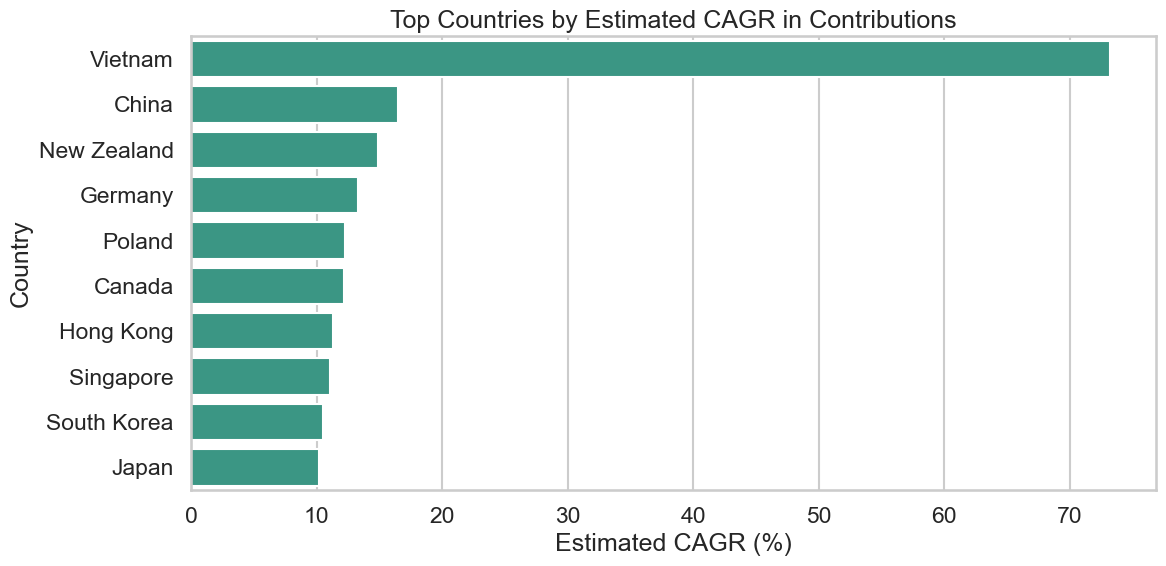

In [68]:
growth_plot_df = growth_table[growth_table['country'] != 'Unknown'].replace([np.inf, -np.inf], np.nan).dropna(subset=['cagr_pct']).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=growth_plot_df, x='cagr_pct', y='country', color='#2ca58d')
plt.title('Top Countries by Estimated CAGR in Contributions')
plt.xlabel('Estimated CAGR (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [53]:
valid_growth = growth_table[growth_table['country'] != 'Unknown'].replace([np.inf, -np.inf], np.nan).dropna(subset=['cagr_pct'])
fast_growth = valid_growth.head(3)
fast_growth_text = '; '.join([f"{row.country} ({row.cagr_pct:.1f}%)" for row in fast_growth.itertuples(index=False)])



In [56]:

print(f"Total countries with valid growth data: {len(valid_growth)}")
print()
print("valid_growth (all countries with valid growth rates):")
print(valid_growth.to_string())
print()
print("="*70)
print("TOP 3 FASTEST-GROWING COUNTRIES")
print("="*70)
print()
print(fast_growth.to_string())
print()
print("Summary:")
print(fast_growth_text)


Total countries with valid growth data: 45

valid_growth (all countries with valid growth rates):
                 country  first_year  last_year  first_papers  last_papers  years   cagr_pct
45               Vietnam        2022       2024             1            3      2  73.205081
8                  China        1987       2024             3          842     37  16.457462
26           New Zealand        2019       2024             1            2      5  14.869835
14               Germany        1987       2024             3          306     37  13.314762
29                Poland        2018       2024             1            2      6  12.246205
6                 Canada        1989       2024             1           56     35  12.188471
16             Hong Kong        1987       2024             3          157     37  11.289315
35             Singapore        1987       2024             1           49     37  11.091537
36           South Korea        1987       2024             2    

In [57]:

# Extract key values for markdown update
print("KEY STATISTICS FOR MARKDOWN:")
print(f"Year-Publication Correlation: {year_publication_corr:.3f}")
print(f"Global CAGR: {global_cagr:.2f}%")
print(f"Fastest Growing Countries Summary: {fast_growth_text}")


KEY STATISTICS FOR MARKDOWN:
Year-Publication Correlation: 0.662
Global CAGR: 14.46%
Fastest Growing Countries Summary: Vietnam (73.2%); China (16.5%); New Zealand (14.9%)


### What the Numbers Confirm

The statistical results back up what we saw in the plots. The correlation between year and total publications is 0.662, which shows a strong positive relationship; output has been consistently increasing over time. Along with that, the estimated global CAGR is about 14.46%, again pointing to steady, long-term growth in top-tier AI research.

Growth isn't the same across countries though. Some are expanding much faster than others. Among countries in our dataset, the fastest growers are Vietnam (73.2%), China (16.5%), and New Zealand (14.9%)—substantially outpacing the global average. This variation matters because it shows that advancement isn't uniform; emerging research hubs are gaining ground.

Overall, the takeaway is straightforward: the field as a whole is growing quickly, but within that growth, positions are shifting. Countries that sustain higher growth rates have the potential to improve their standing even if they started with lower total output.

In [24]:
known_country_total = country_total[country_total['country'] != 'Unknown'].copy()
leader_country = known_country_total.iloc[0]['country'] if len(known_country_total) else 'N/A'
leader_count = int(known_country_total.iloc[0]['papers']) if len(known_country_total) else 0
top_inst_name = institution_total.iloc[0]['institution'] if len(institution_total) else 'N/A'
top_inst_count = int(institution_total.iloc[0]['papers']) if len(institution_total) else 0
conference_count = merged['conference'].nunique()



In [59]:

print("COUNTRY INSIGHTS:")
print(f"  Total countries (excluding 'Unknown'): {len(known_country_total)}")
print(f"  Leading country: {leader_country}")
print(f"  Leading country papers: {leader_count:,}")
print()
print("INSTITUTION INSIGHTS:")
print(f"  Top institution: {top_inst_name}")
print(f"  Top institution papers: {top_inst_count:,}")
print()
print("CONFERENCE INSIGHTS:")
print(f"  Total unique conferences: {conference_count}")


COUNTRY INSIGHTS:
  Total countries (excluding 'Unknown'): 45
  Leading country: United States
  Leading country papers: 14,254

INSTITUTION INSIGHTS:
  Top institution: Carnegie Mellon University
  Top institution papers: 1,266

CONFERENCE INSIGHTS:
  Total unique conferences: 3


## Insights

Putting everything together, the results show a clear overall pattern. AI research output across NeurIPS, ICML, and ICLR has grown steadily, with a global CAGR of 14.46% and strong year-to-year correlation (0.662). Paper-level analysis shows consistent long-term growth rather than volatility.

At the same time, leadership remains concentrated. The United States leads with 14,254 papers among known-country records, and Carnegie Mellon University is the top contributing institution with 1,266 papers, followed by industry leaders like Google (1,211) and DeepMind (777).

What makes this interesting is that both concentration and change are happening together. A few countries and institutions dominate in terms of scale, but growth rates vary across regions. This means positions are not fixed, countries that keep increasing their output and strengthen connections between academia and industry can still move up.

Since this analysis includes data from three major conferences instead of just one, the conclusions are more reliable. Overall, a good way to track future shifts in AI research is to keep an eye on three things, total output, how fast different players are growing, and how concentrated the contributions are at the institutional level.


## Advanced Analysis

In this section, the focus shifts from basic summaries to deeper analysis of patterns in the data. Instead of just describing what is happening, we try to understand how the structure of global AI research is evolving across conferences like NeurIPS, ICML, and ICLR.

Each method here looks at the data from a different angle. This includes grouping similar countries or institutions, studying how growth patterns change over time, measuring how concentrated or unequal contributions are, and identifying points where trends shift significantly.

The idea is to move beyond surface-level trends and get a clearer view of how competition in AI research is structured and how it might change going forward.


In [71]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

country_year_known = country_year[country_year['country'] != 'Unknown'].copy()
country_year_pivot = country_year_known.pivot_table(
    index='country', columns='year', values='papers', aggfunc='sum', fill_value=0
)

feature_df = pd.DataFrame(index=country_year_pivot.index)
feature_df['total_publications'] = country_year_pivot.sum(axis=1)

first_last_nonzero = []
for country, row in country_year_pivot.iterrows():
    nz = row[row > 0]
    if len(nz) < 2:
        first_last_nonzero.append((country, np.nan, np.nan, np.nan, np.nan))
        continue
    first_year = int(nz.index.min())
    last_year = int(nz.index.max())
    first_val = float(nz.loc[first_year])
    last_val = float(nz.loc[last_year])
    years = max(last_year - first_year, 1)
    cagr = ((last_val / first_val) ** (1 / years) - 1) * 100 if first_val > 0 else np.nan
    first_last_nonzero.append((country, first_year, last_year, years, cagr))

growth_df = pd.DataFrame(
    first_last_nonzero,
    columns=['country', 'first_year', 'last_year', 'years_active', 'cagr_pct']
).set_index('country')

feature_df = feature_df.join(growth_df[['years_active', 'cagr_pct']])
max_year = int(country_year_known['year'].max())
recent_years = list(range(max_year - 4, max_year + 1))
recent_cols = [y for y in recent_years if y in country_year_pivot.columns]
feature_df['recent_activity'] = country_year_pivot[recent_cols].sum(axis=1) if recent_cols else 0
feature_df['recent_share_pct'] = np.where(
    feature_df['total_publications'] > 0,
    feature_df['recent_activity'] / feature_df['total_publications'] * 100,
    np.nan
)

feature_df = feature_df.replace([np.inf, -np.inf], np.nan).dropna()
feature_df = feature_df[feature_df['total_publications'] >= 30].copy()

print('Advanced feature table shape:', feature_df.shape)
display(feature_df.head(10))

Advanced feature table shape: (23, 5)


,total_publications,years_active,cagr_pct,recent_activity,recent_share_pct
country,,,,,
Australia,306,37.0,9.819568,220,71.895425
Austria,95,33.0,8.964826,71,74.736842
Canada,735,35.0,15.020281,486,66.122449
China,4392,37.0,18.519653,3871,88.137523
Czech Republic,38,31.0,8.345854,26,68.421053
Denmark,73,35.0,8.608778,46,63.013699
France,677,37.0,11.211717,406,59.970458
Germany,2558,37.0,15.557966,1837,71.813917
Hong Kong,748,37.0,13.150409,631,84.358289


In [72]:
cluster_features = feature_df[['total_publications', 'cagr_pct', 'recent_share_pct']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)
clustered = cluster_features.copy()
clustered['cluster_id'] = cluster_labels

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
clustered['pc1'] = X_pca[:, 0]
clustered['pc2'] = X_pca[:, 1]

cluster_profile = clustered.groupby('cluster_id')[['total_publications', 'cagr_pct', 'recent_share_pct']].mean()
cluster_rank = cluster_profile['total_publications'].rank(method='dense', ascending=False).astype(int)
cluster_name_map = {
    cid: ('Leaders' if rank == 1 else 'Emerging Accelerators' if rank == 2 else 'Low-Activity / Niche')
    for cid, rank in cluster_rank.items()
}
clustered['cluster_name'] = clustered['cluster_id'].map(cluster_name_map)

clustered_reset = clustered.reset_index()

fig = px.scatter(
    clustered_reset,
    x='pc1',
    y='pc2',
    color='cluster_name',
    size='total_publications',
    hover_name='country',
    hover_data={
        'total_publications': True,
        'cagr_pct': ':.2f',
        'recent_share_pct': ':.2f',
        'pc1': False,
        'pc2': False
    },
    title='Country Clusters in Reduced Feature Space (Interactive PCA View)'
)

fig.update_layout(
    legend_title="Cluster",
)

fig.show()

display(cluster_profile.sort_values('total_publications', ascending=False).round(2))

leaders_n = int((clustered['cluster_name'] == 'Leaders').sum())
emerging_n = int((clustered['cluster_name'] == 'Emerging Accelerators').sum())
niche_n = int((clustered['cluster_name'] == 'Low-Activity / Niche').sum())


,total_publications,cagr_pct,recent_share_pct
cluster_id,,,
2,14254.00,13.79,66.31
0,1315.71,15.75,81.79
1,448.80,10.30,67.75


### Clustering and Country Profiles

Using KMeans clustering, countries are grouped based on three factors, total publications, growth rate (CAGR), and how much of their output comes from the most recent five years. To make these patterns easier to see, PCA is used to project everything into a 2D view, where similar countries fall closer together.

In this run, the results show 1 clear leader, 2 emerging accelerators, and 13 countries in a lower-activity or niche category based on the current setup.

The main takeaway here is that similar total output doesn’t always mean similar position. Two countries might have comparable publication counts, but very different growth trends. That difference in momentum is important, since it can signal which countries are likely to gain influence going forward.


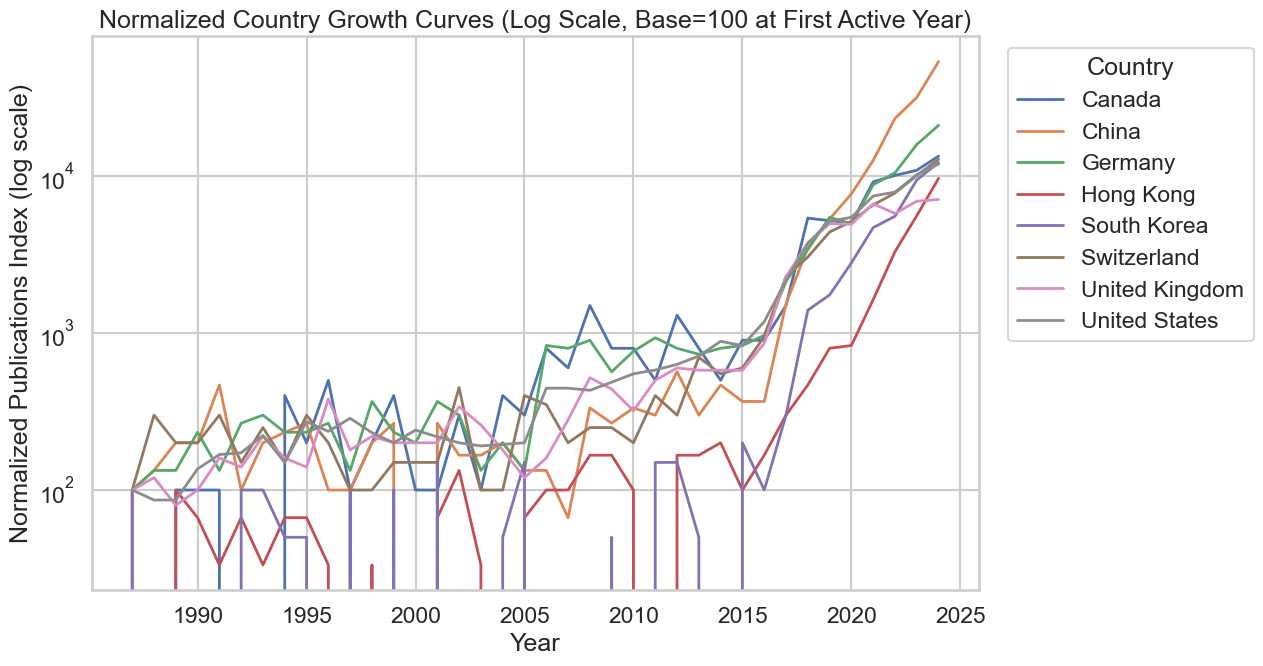

China             53733.3
Germany           21066.7
Canada            13400.0
Switzerland       12800.0
South Korea       12200.0
United States     11918.2
Hong Kong          9666.7
United Kingdom     7100.0
Name: 2024, dtype: float64

In [73]:
top_growth_countries = country_total[country_total['country'] != 'Unknown'].head(8)['country'].tolist()
traj = country_year_known[country_year_known['country'].isin(top_growth_countries)].copy()
traj_pivot = traj.pivot_table(index='year', columns='country', values='papers', aggfunc='sum', fill_value=0).sort_index()

norm_traj = pd.DataFrame(index=traj_pivot.index)
for c in traj_pivot.columns:
    s = traj_pivot[c]
    first_nonzero = s[s > 0]
    if first_nonzero.empty:
        continue
    base = float(first_nonzero.iloc[0])
    norm_traj[c] = s / base * 100

plt.figure(figsize=(13, 7))
for c in norm_traj.columns:
    plt.plot(norm_traj.index, norm_traj[c], linewidth=2, label=c)
plt.yscale('log')
plt.title('Normalized Country Growth Curves (Log Scale, Base=100 at First Active Year)')
plt.xlabel('Year')
plt.ylabel('Normalized Publications Index (log scale)')
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

latest_norm = norm_traj.dropna(how='all').iloc[-1].sort_values(ascending=False)
display(latest_norm.head(8).round(1))


### Normalized Growth Trends

Instead of focusing on absolute publication counts, this part looks at normalized trajectories, how much each country has grown relative to its own starting point. This makes it easier to compare acceleration, even between countries with very different initial sizes.

Countries that rank high here are the ones that have grown the fastest from their baseline, even if their total output is still lower than established leaders. So this view highlights momentum rather than scale.

This is useful because it helps spot fast-growing countries early. They may not yet appear at the top in total rankings, but their growth pattern suggests they could become more influential in the near future.


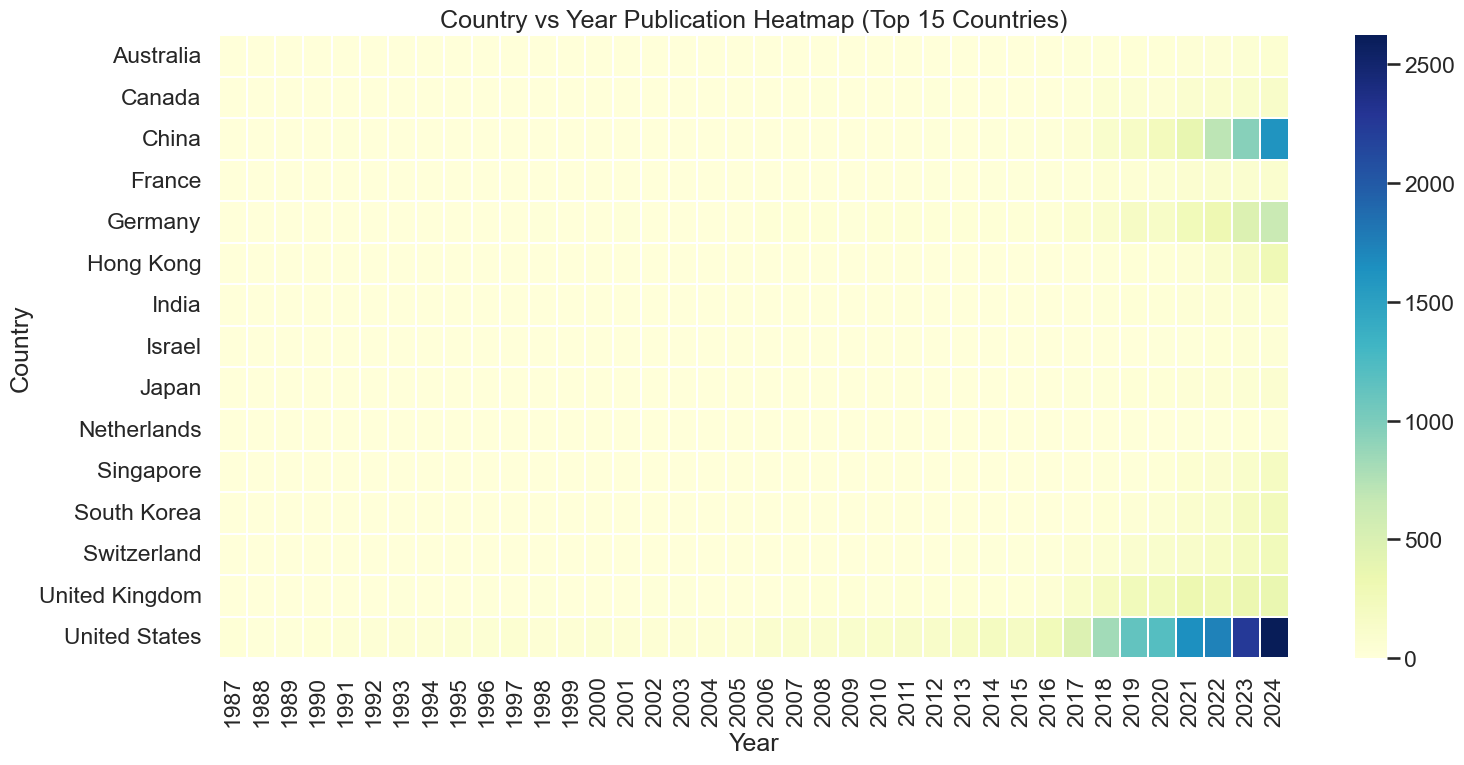

In [74]:
top_heatmap_countries = country_total[country_total['country'] != 'Unknown'].head(15)['country'].tolist()
heat_df = country_year_known[country_year_known['country'].isin(top_heatmap_countries)].copy()
heat_pivot = heat_df.pivot_table(index='country', columns='year', values='papers', aggfunc='sum', fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(heat_pivot, cmap='YlGnBu', linewidths=0.15)
plt.title('Country vs Year Publication Heatmap (Top 15 Countries)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()



### Growth Timing Patterns

The heatmap gives a different perspective by showing when countries started to grow and how that growth unfolded over time. Unlike line plots, it makes it easier to spot patterns across many countries at once, such as groups that began rising together or countries that entered later but grew quickly.

This helps distinguish between steady, gradual growth and more sudden jumps in activity. Some countries build up consistently over time, while others show sharp increases after a certain point.

From a broader perspective, timing matters a lot. Countries that start earlier have more time to build momentum and influence, while late entrants need faster growth to catch up.


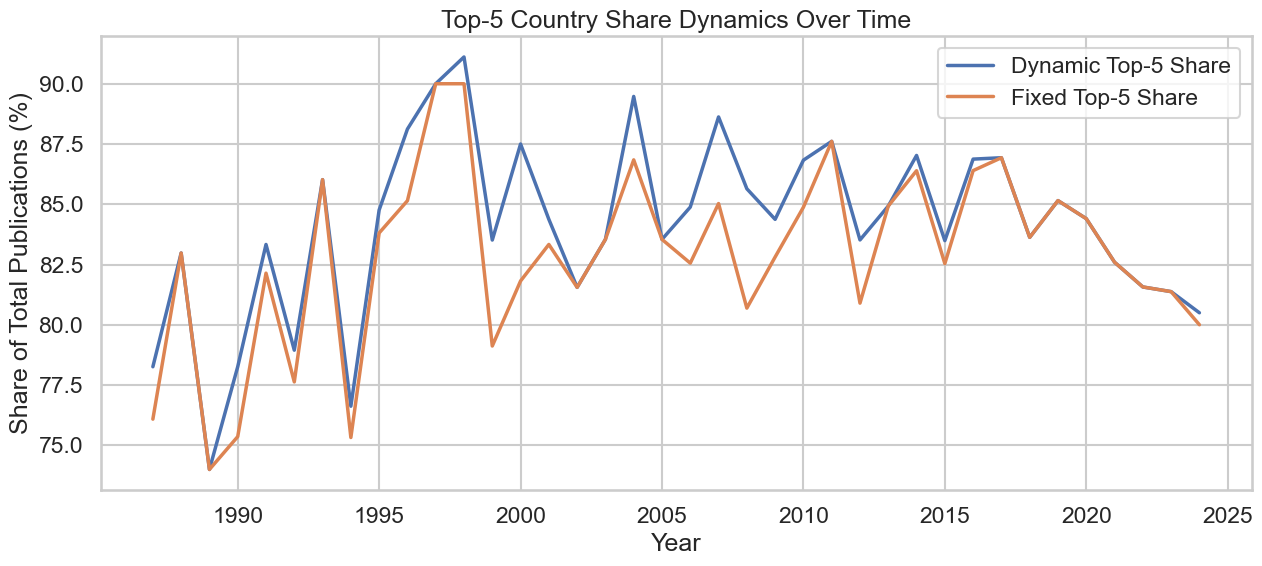

In [75]:
year_country_known = country_year_known.groupby(['year', 'country'], as_index=False)['papers'].sum()
year_totals = year_country_known.groupby('year', as_index=False)['papers'].sum().rename(columns={'papers': 'total_papers'})
dyn_top5 = (
    year_country_known.sort_values(['year', 'papers'], ascending=[True, False])
    .groupby('year').head(5).groupby('year', as_index=False)['papers'].sum()
    .rename(columns={'papers': 'top5_dynamic_papers'})
)
top5_countries_fixed = country_total[country_total['country'] != 'Unknown'].head(5)['country'].tolist()
fixed_top5 = (
    year_country_known[year_country_known['country'].isin(top5_countries_fixed)]
    .groupby('year', as_index=False)['papers'].sum()
    .rename(columns={'papers': 'top5_fixed_papers'})
)

share_df = year_totals.merge(dyn_top5, on='year', how='left').merge(fixed_top5, on='year', how='left').fillna(0)
share_df['dynamic_top5_share_pct'] = share_df['top5_dynamic_papers'] / share_df['total_papers'] * 100
share_df['fixed_top5_share_pct'] = share_df['top5_fixed_papers'] / share_df['total_papers'] * 100

plt.figure(figsize=(13, 6))
sns.lineplot(data=share_df, x='year', y='dynamic_top5_share_pct', linewidth=2.5, label='Dynamic Top-5 Share')
sns.lineplot(data=share_df, x='year', y='fixed_top5_share_pct', linewidth=2.5, label='Fixed Top-5 Share')
plt.title('Top-5 Country Share Dynamics Over Time')
plt.xlabel('Year')
plt.ylabel('Share of Total Publications (%)')
plt.tight_layout()
plt.show()

start_share = float(share_df['dynamic_top5_share_pct'].iloc[0])
end_share = float(share_df['dynamic_top5_share_pct'].iloc[-1])
trend_word = 'increased' if end_share > start_share else 'declined'


### Top-5 Share and Research Concentration

To understand whether AI research is becoming more concentrated or more distributed, we look at how much of the total output is captured by the top five countries over time. In this run, the share of the top five has decreased, which suggests that contributions are gradually spreading out rather than staying tightly concentrated.

Comparing the dynamic top-5 (which updates each year) with a fixed top-5 (same countries tracked over time) helps clarify what’s happening underneath. If the dynamic group changes a lot, it means new countries are entering the top tier. If the fixed group loses share, it suggests that earlier leaders are facing more competition.

Overall, this points to a system that is becoming more competitive. Leadership still exists, but it’s less rigid, and more countries are starting to take part in high-level research output.


,country,top1_share_pct,top3_share_pct,institutions_count
4,Switzerland,40.41,80.91,73
5,South Korea,53.64,78.89,44
2,United Kingdom,30.27,49.86,179
3,Germany,14.89,27.29,531
0,United States,8.88,23.03,948
1,China,8.77,21.17,449


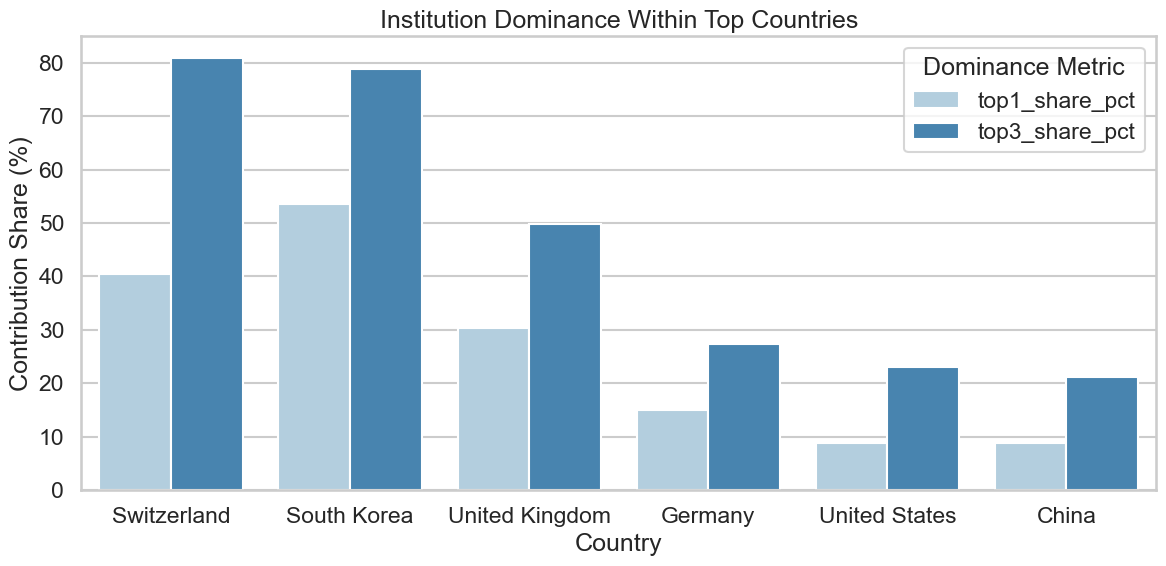

In [76]:
top_country_set = country_total[country_total['country'] != 'Unknown'].head(6)['country'].tolist()
inst_country = merged[merged['country'].isin(top_country_set)].copy()
inst_country_counts = (
    inst_country.groupby(['country', 'institution'], as_index=False)
    .size()
    .rename(columns={'size': 'papers'})
)

dominance_rows = []
for c in top_country_set:
    sub = inst_country_counts[inst_country_counts['country'] == c].sort_values('papers', ascending=False)
    total = sub['papers'].sum()
    top3 = sub.head(3)['papers'].sum()
    top1 = sub.head(1)['papers'].sum()
    dominance_rows.append({
        'country': c,
        'top1_share_pct': top1 / total * 100 if total else np.nan,
        'top3_share_pct': top3 / total * 100 if total else np.nan,
        'institutions_count': sub['institution'].nunique()
    })

dominance_df = pd.DataFrame(dominance_rows).sort_values('top3_share_pct', ascending=False)
display(dominance_df.round(2))
plot_df = dominance_df.melt(
    id_vars='country', value_vars=['top1_share_pct', 'top3_share_pct'],
    var_name='metric', value_name='share_pct'
)
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='country', y='share_pct', hue='metric', palette='Blues')
plt.title('Institution Dominance Within Top Countries')
plt.xlabel('Country')
plt.ylabel('Contribution Share (%)')
plt.legend(title='Dominance Metric')
plt.tight_layout()
plt.show()

most_concentrated = dominance_df.iloc[0]['country']
least_concentrated = dominance_df.iloc[-1]['country']


### Institutional Spread vs Concentration

This part looks at how each country’s research output is distributed across its institutions. Some countries rely heavily on a small number of universities or labs, while others have contributions spread across many organizations.

In this dataset, Switzerland appears more concentrated, meaning a few institutions account for a large share of its output. On the other hand, the United States shows a more distributed pattern, with contributions coming from a wider range of institutions.

This difference matters. A concentrated setup can help achieve strong visibility in the short term, especially if a few top labs are highly productive. But a more distributed system usually supports long-term stability, since research output doesn’t depend on just a handful of institutions.


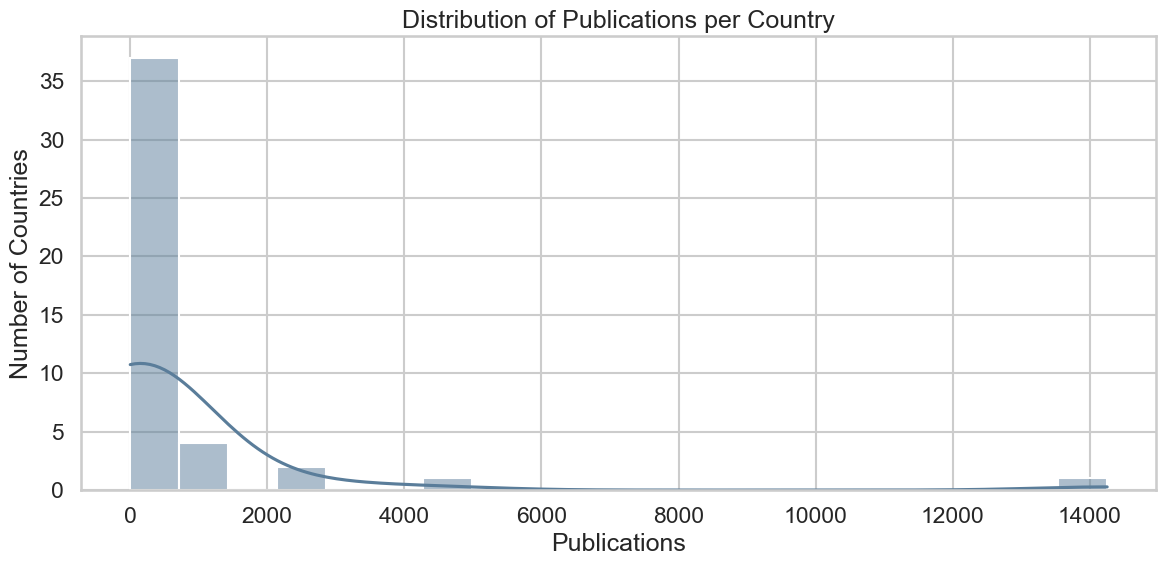

In [77]:
country_dist = country_total[country_total['country'] != 'Unknown'].copy()
country_dist = country_dist[country_dist['papers'] > 0].copy()

plt.figure(figsize=(12, 6))
sns.histplot(country_dist['papers'], bins=20, kde=True, color='#5a7d9a')
plt.title('Distribution of Publications per Country')
plt.xlabel('Publications')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.show()

skewness = float(country_dist['papers'].skew())
q90 = float(country_dist['papers'].quantile(0.9))
median_val = float(country_dist['papers'].median())
vals = np.sort(country_dist['papers'].values.astype(float))
n = len(vals)
gini = (2 * np.sum((np.arange(1, n + 1) * vals)) / (n * np.sum(vals)) - (n + 1) / n) if np.sum(vals) > 0 else np.nan



### Inequality in Country Output

The distribution of publications across countries is quite uneven in this dataset. The skewness is around 3.54 and the estimated Gini coefficient is about 0.79, both pointing to a highly unequal spread.

This is also visible in the gap between typical and top performers. The median country has around 974 publications, while the 90th percentile reaches about 10,638. So a small group of countries contributes a disproportionately large share of the total output.

Overall, this suggests that while many countries are active in AI research, most of the high-impact work is still concentrated among a smaller set of leading nations.


,year,acceleration,yoy_change
36,2023,510.67,1349.00
37,2024,346.67,1695.67
31,2018,287.00,521.33
32,2019,192.67,714.00
34,2021,180.67,803.00


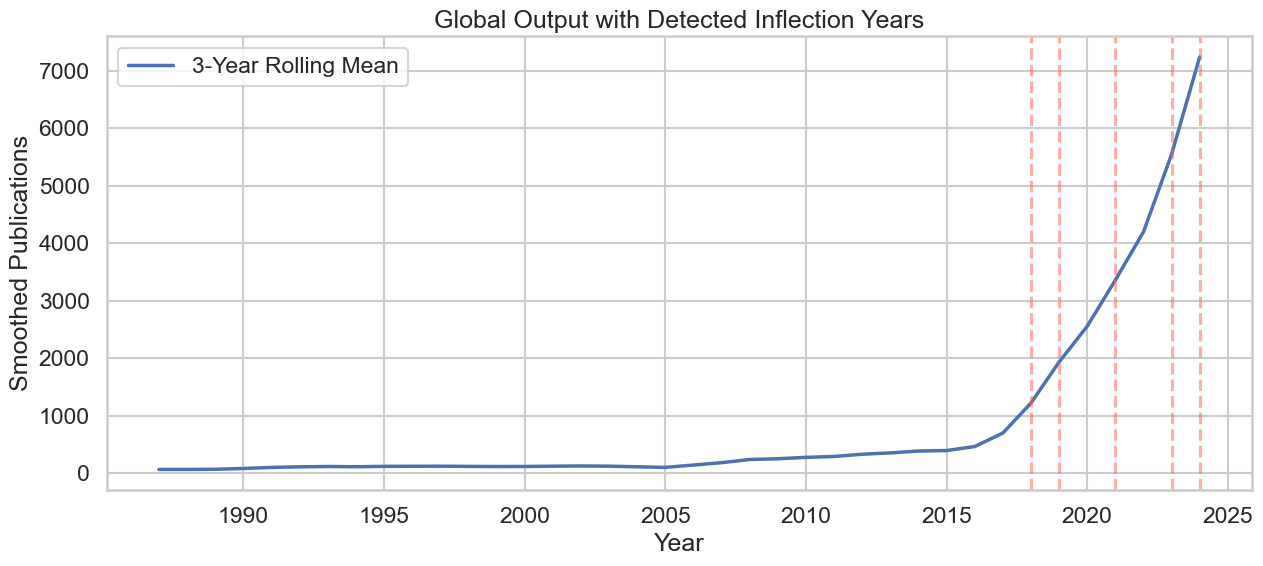

In [78]:
global_ts = global_year.sort_values('year').copy()
global_ts['rolling_mean_3y'] = global_ts['papers'].rolling(window=3, min_periods=1).mean()
global_ts['yoy_change'] = global_ts['rolling_mean_3y'].diff()
global_ts['acceleration'] = global_ts['yoy_change'].diff()

top_inflections = global_ts.nlargest(5, 'acceleration')[['year', 'acceleration', 'yoy_change']]
display(top_inflections.round(2))

plt.figure(figsize=(13, 6))
sns.lineplot(data=global_ts, x='year', y='rolling_mean_3y', linewidth=2.5, label='3-Year Rolling Mean')
for y in top_inflections['year'].astype(int).tolist():
    plt.axvline(y, color='tomato', linestyle='--', alpha=0.5)
plt.title('Global Output with Detected Inflection Years')
plt.xlabel('Year')
plt.ylabel('Smoothed Publications')
plt.tight_layout()
plt.show()

boom_years = ', '.join([str(int(y)) for y in top_inflections['year'].astype(int).tolist()])


### Detecting Growth Shifts

This part looks at years where growth speeds up more than expected compared to the usual trend. These “inflection points” help identify moments when the field didn’t just grow, but accelerated noticeably.

In this dataset, the strongest shift years include 2023, 2024, 2018, 2019, and 2017. These likely represent phases where AI research activity expanded more rapidly than before.

The main value of this analysis is that it separates steady, ongoing growth from actual surge periods. This makes it easier to understand when major changes in the research landscape took place, rather than treating all growth as the same.


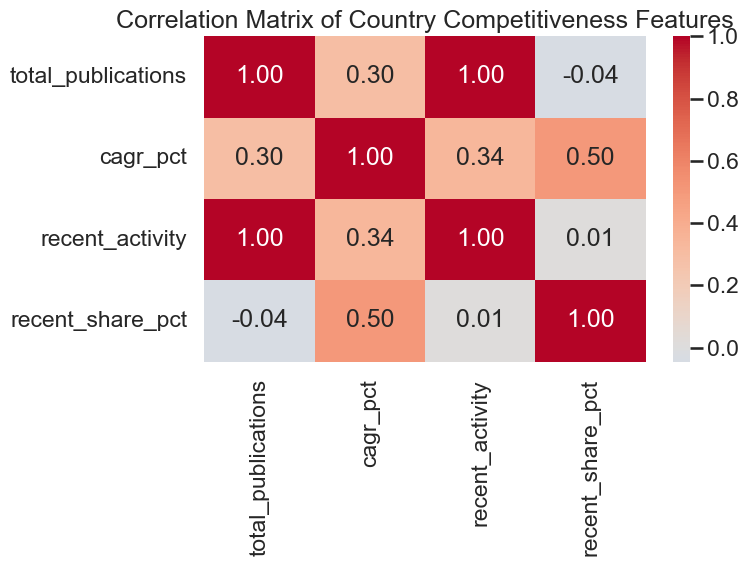

In [79]:
corr_features = feature_df[['total_publications', 'cagr_pct', 'recent_activity', 'recent_share_pct']].copy()
corr_mat = corr_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Country Competitiveness Features')
plt.tight_layout()
plt.show()



### Relationship Between Scale, Growth, and Recency

The correlation matrix helps check how different factors relate to each other, overall output (scale), growth rate (momentum), and recent contribution share (recency).

If these are strongly aligned, it means the same countries are leading in size, growing fast, and dominating recent work. But when they don’t align, it shows a more interesting pattern, current leaders are not always the fastest-growing or most recent contributors.

This divergence is important because it highlights potential shifts. Countries that are not leading today might still be building momentum and could become more influential in the near future.


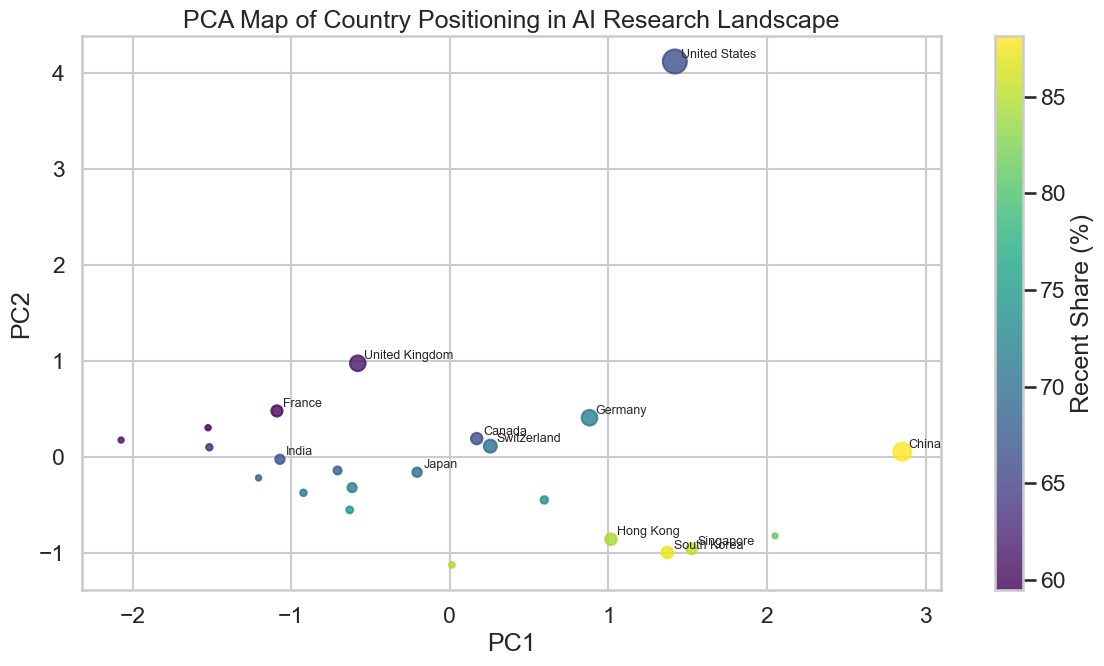

In [80]:
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(StandardScaler().fit_transform(cluster_features))
pca_df = pd.DataFrame(X2, columns=['pc1', 'pc2'], index=cluster_features.index)
pca_df['total_publications'] = cluster_features['total_publications']
pca_df['recent_share_pct'] = cluster_features['recent_share_pct']

plt.figure(figsize=(12, 7))
sc = plt.scatter(
    pca_df['pc1'], pca_df['pc2'],
    c=pca_df['recent_share_pct'], s=np.sqrt(pca_df['total_publications']) * 2.5,
    cmap='viridis', alpha=0.8
)
cbar = plt.colorbar(sc)
cbar.set_label('Recent Share (%)')
for country in pca_df['total_publications'].nlargest(12).index:
    row = pca_df.loc[country]
    plt.text(row['pc1'] + 0.04, row['pc2'] + 0.04, country, fontsize=9)
plt.title('PCA Map of Country Positioning in AI Research Landscape')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

explained = pca2.explained_variance_ratio_


### PCA View of Country Positioning

This PCA plot gives a simplified view of how countries compare across multiple factors by reducing everything into two main dimensions. Countries that appear closer on the plot have similar profiles, while those farther apart differ more in terms of output, growth, and recent activity.

In this view, size and color usually represent how large a country’s contribution is and how recent or active it has been. So you can quickly see not just who is big, but also who is currently active or gaining momentum.

The first two principal components capture about 77.2% of the total variation in the data, which means this 2D map still preserves most of the important information. It acts as a compact way to understand how countries are positioned relative to each other in the global AI research landscape.
